# Part 2 — Patient-Level Image Modeling and Serial Alert-Burden Simulation

Part 1 produced an audited image-level table, a long-format label-transition table, and
a run manifest. Part 2 trains a lightweight image model on fixed embeddings, freezes
thresholds on validation data, generates held-out predictions, and simulates the serial
alert stream.

---

## 1. Objectives, estimands, and non-claims

### 1.1 Primary estimand, stated before any result exists

In the held-out test split, restricted to sequence-eligible follow-up encounters with
available within-split history, at pathology-specific thresholds locked on validation
data, the proportion of model-fired alerts falling into each of three mutually exclusive
categories: `false_alert`, `redundant_alert`, `first_observed_positive_alert`.

The primary redundancy predicate is `label_historical`. The secondary predicate is
`prediction_historical`. They are reported side by side and never combined.

### 1.2 Denominators, all reported

A single image contributes one opportunity per selected pathology, so an image can fire
several alerts. Every burden quantity is therefore reported per 100 follow-up images,
per patient, and per patient-pathology opportunity. Reporting only one of these invites
misreading, because a minority of frequently-imaged patients supplies a large share of
all images.

### 1.3 Three leakage boundaries enforced in code

1. **Patient leakage.** Splits are patient-disjoint and asserted, never assumed.
2. **History leakage.** Serial history for the test stream is **recomputed from scratch
   within the test split**. Part 1's history columns were derived over each patient's
   full sequence and are deliberately not reused for the test decomposition, so that no
   training or validation encounter can enter a test-side history window even if a
   future split were not patient-disjoint.
3. **Threshold leakage.** Thresholds are selected on validation probabilities only and
   locked to disk before any test metric is computed.

The image model receives embedding features only. No sequence position, follow-up
number, prior label, or alert-history variable is ever an input. History is applied
strictly after image-level predictions are frozen.

### 1.4 Non-claims

This is a retrospective shadow-mode simulation on weak, report-derived labels. It does
not measure notifications, clinician behaviour, workload, trust, override behaviour,
clinical outcomes, safety, cost, or patient benefit. A repeated positive label may be
entirely appropriate to re-alert on in real practice; nothing here establishes
otherwise. `first_observed_positive_alert` denotes a first positive weak label within
the available sequence and nothing more. No simulated suppression policy may be
described as safe, unnecessary, or ready for deployment on this evidence.

### 1.5 Two additions carried over from the Part 1 review

Part 1 did not persist the age-consistency flags, so they are recomputed here from
`age_numeric` and `sequence_position_ordinal`. They support a pre-specified sensitivity
analysis excluding patients with gross internal inconsistencies in recorded age. This is a
limited data-integrity check against obvious ordering anomalies. It does not validate
calendar time, elapsed interval, or true clinical chronology.

## 2. Load and validate Part 1 artifacts

Nothing downstream runs until every structural check passes. Failures raise with a
diagnostic rather than warning and continuing.

In [101]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import platform
import random
import sys
import time
import warnings
from dataclasses import dataclass, asdict, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)

# ---------------------------- PATHS (edit these) -----------------------------
PART1_OUTPUT_DIR: Path = Path(r"C:\Users\kruta\Downloads\part1_outputs")
PART2_OUTPUT_DIR: Path = Path(r"C:\Users\kruta\Downloads\part2_outputs")
IMAGE_ROOT: Path = Path(r"C:\Users\kruta\Downloads\NIH Chest X-rays")
# -----------------------------------------------------------------------------

P1_CACHE = PART1_OUTPUT_DIR / "cache"
P1_TABLES = PART1_OUTPUT_DIR / "tables"
P1_LOGS = PART1_OUTPUT_DIR / "logs"


def require_artifact(path: Path, what: str) -> Path:
    """Return `path` or raise with a diagnostic naming what is missing and where."""
    if Path(path).exists():
        return Path(path)
    parent = Path(path).parent
    listing = sorted(p.name for p in parent.iterdir())[:25] if parent.exists() else []
    raise FileNotFoundError(
        f"Missing Part 1 artifact: {what}\n  expected: {path}\n"
        f"  parent {'exists' if parent.exists() else 'MISSING'}; contains: {listing}\n"
        "  Re-run Part 1, or correct PART1_OUTPUT_DIR above."
    )


def _read_any(stem: Path) -> pd.DataFrame:
    """Read a Part 1 table saved as either parquet or gzipped CSV."""
    pq, gz = stem.with_suffix(".parquet"), Path(str(stem) + ".csv.gz")
    if pq.exists():
        return pd.read_parquet(pq)
    if gz.exists():
        return pd.read_csv(gz)
    require_artifact(pq, f"{stem.name} (.parquet or .csv.gz)")
    raise AssertionError("unreachable")


def load_part1_artifacts() -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, object]]:
    """Load the Part 1 wide table, long transition table, and run manifest."""
    manifest_path = require_artifact(P1_LOGS / "part1_run_manifest.json", "run manifest")
    manifest = json.loads(manifest_path.read_text())
    wide = _read_any(P1_CACHE / "part1_image_level")
    long = _read_any(P1_CACHE / "part1_transition_long")
    return wide, long, manifest


def validate_part1_manifest(manifest: Dict[str, object]) -> List[str]:
    """Check the manifest carries the keys Part 2 depends on."""
    required = ["pathologies", "dataset_fingerprint", "wide_rows", "long_rows",
                "random_seed", "redundancy_definitions", "tables_saved"]
    missing = [k for k in required if k not in manifest]
    if missing:
        raise KeyError(f"Part 1 manifest is missing keys: {missing}")
    return list(manifest["pathologies"])


def validate_image_level_schema(wide: pd.DataFrame) -> None:
    """Structural checks on the Part 1 image-level table."""
    need = ["Image Index", "Patient ID", "sequence_position_ordinal",
            "patient_sequence_length", "is_index_encounter", "sequence_eligible",
            "sequence_eligible_metadata", "strict_history_eligible", "image_path",
            "image_exists", "sex_group", "age_band", "projection_group", "age_numeric",
            "official_split"]
    missing = [c for c in need if c not in wide.columns]
    if missing:
        raise KeyError(f"Part 1 image-level table is missing columns: {missing}")
    dup = int(wide["Image Index"].duplicated().sum())
    if dup:
        raise ValueError(f"{dup} duplicate Image Index values in the image-level table.")
    if wide["Patient ID"].isna().any():
        raise ValueError("Null Patient ID present in the image-level table.")


def validate_transition_schema(long: pd.DataFrame, wide: pd.DataFrame,
                               pathologies: Sequence[str]) -> None:
    """Structural checks on the Part 1 long transition table."""
    need = ["Image Index", "Patient ID", "pathology", "label_current",
            "sequence_position_ordinal", "is_index_encounter", "sequence_eligible",
            "history_available", "strict_history_eligible", "label_ever_prior",
            "label_prior_encounter"]
    missing = [c for c in need if c not in long.columns]
    if missing:
        raise KeyError(f"Part 1 long table is missing columns: {missing}")

    expected = len(wide) * len(pathologies)
    if len(long) != expected:
        raise ValueError(f"Long table has {len(long):,} rows; expected "
                         f"{len(wide):,} images x {len(pathologies)} pathologies "
                         f"= {expected:,}.")
    bad = set(long["pathology"].astype(str).unique()) - set(pathologies)
    if bad:
        raise ValueError(f"Unrecognised pathology values in the long table: {sorted(bad)}")
    if long.duplicated(["Image Index", "pathology"]).any():
        raise ValueError("Duplicate (Image Index, pathology) rows in the long table.")
    orphan = set(long["Image Index"]) - set(wide["Image Index"])
    if orphan:
        raise ValueError(f"{len(orphan):,} long-table image IDs absent from the wide table.")


def validate_fingerprint_alignment(wide: pd.DataFrame, manifest: Dict[str, object],
                                   pathologies: Sequence[str]) -> Dict[str, object]:
    """Recompute the Part 1 dataset fingerprint and compare with the manifest."""
    cols = ["Image Index", "Patient ID", "followup_number_numeric",
            "sequence_position_ordinal", *pathologies]
    sub = wide.loc[:, cols]
    h = hashlib.sha1()
    h.update("|".join(cols).encode("utf-8"))
    h.update(str(sub.shape).encode("utf-8"))
    h.update(pd.util.hash_pandas_object(sub, index=False).values.tobytes())
    got, want = h.hexdigest(), str(manifest["dataset_fingerprint"])
    if got != want:
        warnings.warn(
            f"Dataset fingerprint mismatch.\n  manifest: {want}\n  recomputed: {got}\n"
            "The artifact differs from the one the manifest describes. This is expected "
            "only if you edited the wide table after Part 1 (for example by adding "
            "columns). Investigate before trusting any result.", UserWarning)
    return {"fingerprint_manifest": want, "fingerprint_recomputed": got,
            "fingerprint_match": got == want}


print("Loading Part 1 artifacts ...")
p1_wide, p1_long, P1_MANIFEST = load_part1_artifacts()
PATHOLOGIES: List[str] = validate_part1_manifest(P1_MANIFEST)
validate_image_level_schema(p1_wide)
validate_transition_schema(p1_long, p1_wide, PATHOLOGIES)
FP = validate_fingerprint_alignment(p1_wide, P1_MANIFEST, PATHOLOGIES)

_p1_tables_present = sorted(p.name for p in P1_TABLES.glob("*.csv"))
_p1_tables_expected = ["data_coverage_report.csv", "followup_structure_audit.csv",
                       "pathology_transition_summary.csv", "part1_audit_checklist.csv"]
_p1_missing = [t for t in _p1_tables_expected if t not in _p1_tables_present]

print(f"  images        : {len(p1_wide):,}")
print(f"  patients      : {p1_wide['Patient ID'].nunique():,}")
print(f"  long rows     : {len(p1_long):,}  ({len(PATHOLOGIES)} pathologies)")
print(f"  image-linked  : {int(p1_wide['image_exists'].sum()):,}")
print(f"  fingerprint   : {'MATCH' if FP['fingerprint_match'] else 'MISMATCH'}")
print(f"  P1 tables     : {len(_p1_tables_present)} found"
      f"{'' if not _p1_missing else f'; MISSING {_p1_missing}'}")
print("All Part 1 structural validations passed.")

Loading Part 1 artifacts ...
  images        : 112,120
  patients      : 30,805
  long rows     : 1,569,680  (14 pathologies)
  image-linked  : 112,120
  fingerprint   : MATCH
  P1 tables     : 17 found
All Part 1 structural validations passed.


## 3. Reproducible configuration and computational safeguards

The whole analysis specification is frozen in one cell and written to JSON before any
model is fitted. Nothing below this point selects labels, models, thresholds, or cohorts
after seeing a test metric.

**`FAST_MODE` writes to a separate output directory.** Smoke-test results can never
overwrite full-analysis results, and every table produced under `FAST_MODE` carries a
`smoke_test` column so a stray file cannot be mistaken for the real thing.

In [102]:
RANDOM_SEED: int = 42
FAST_MODE: bool = False                 # smoke test; set False for the full analysis

USE_OFFICIAL_SPLIT_IF_PATIENT_DISJOINT: bool = True
TRAIN_FRACTION: float = 0.70
VALIDATION_FRACTION: float = 0.10
TEST_FRACTION: float = 0.20

PRIMARY_MODEL_NAME: str = "linear_multilabel_embedding_head"
PRIMARY_BACKBONE: str = "densenet121_xrv_mimic_ch"
USE_CACHED_EMBEDDINGS: bool = True
ALLOW_MODEL_DOWNLOAD: bool = True           # required to build the backbone at all
ALLOW_FULL_CPU_EMBEDDING_EXTRACTION: bool = True

MIN_TRAIN_POSITIVES: int = 100
MIN_VALIDATION_POSITIVES: int = 25
MIN_TEST_POSITIVES: int = 25
PRIMARY_LABEL_SELECTION_RULE: str = "all labels meeting minimum positive counts in each split"
MAX_PRIMARY_LABELS: int = 13

MAX_EPOCHS: int = 50
EARLY_STOPPING_PATIENCE: int = 7
LEARNING_RATE: float = 1e-3
WEIGHT_DECAY: float = 1e-4
BATCH_SIZE: int = 256
NUM_WORKERS: int = 0
MAX_POS_WEIGHT: float = 20.0                 # cap on positive class weight; reported

PRIMARY_THRESHOLD_RULE: str = "validation_threshold_maximize_f1_with_sensitivity_floor"
MIN_VALIDATION_SENSITIVITY: float = 0.50
FIXED_THRESHOLD_SENSITIVITY_VALUE: float = 0.50

PRIMARY_REDUNDANCY_DEFINITION: str = "label_historical"
SECONDARY_REDUNDANCY_DEFINITION: str = "prediction_historical"
PRIMARY_ALERT_COHORT: str = "followup_only_primary_history"
SCORE_CHANGE_DELTA: float = 0.10      # score-change policy: minimum rise vs prior encounter
STRICT_SENSITIVITY_COHORT: str = "followup_only_strict_history"

MIN_SUBGROUP_IMAGES: int = 100
MIN_SUBGROUP_PATIENTS: int = 25
MIN_SUBGROUP_POSITIVES: int = 10

AGE_CONSISTENCY_TOLERANCE_YEARS: float = 2.0   # allowed backward step before flagging
EMBED_IMAGE_SIZE: int = 224
EMBED_CHUNK_SIZE: int = 2000                   # images per resumable checkpoint
EMBED_SMOKE_TEST_N: int = 256

# ------------------------------- derived setup --------------------------------
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED)
    _TORCH = True
except Exception:
    _TORCH = False

RUN_LABEL = f"{PRIMARY_BACKBONE.split('_')[0]}_sens{int(MIN_VALIDATION_SENSITIVITY*100):02d}"
RUN_TAG = ("smoke" if FAST_MODE else "full") + f"_{RUN_LABEL}"
OUT = PART2_OUTPUT_DIR / RUN_TAG
TABLES, FIGURES, CACHE, LOGS = (OUT / "tables", OUT / "figures",
                                PART2_OUTPUT_DIR / "cache", OUT / "logs")
for d in (OUT, TABLES, FIGURES, CACHE, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=0.92)
matplotlib.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
CB = sns.color_palette("colorblind")

_SAVED_TABLES: List[str] = []
_SAVED_FIGURES: List[str] = []


def save_table(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    """Write a table under the run-tagged output folder, stamping smoke-test status."""
    out = df.copy()
    out.insert(len(out.columns), "smoke_test", FAST_MODE)
    name = name if name.endswith((".csv", ".parquet")) else name + ".csv"
    path = TABLES / name
    out.to_parquet(path, index=index) if name.endswith(".parquet") else \
        out.to_csv(path, index=index)
    _SAVED_TABLES.append(name) if name not in _SAVED_TABLES else None
    print(f"  table  -> {name}  ({len(df):,} x {df.shape[1]})")
    return path


def save_figure(fig: plt.Figure, name: str) -> Path:
    """Write a figure under the run-tagged figures folder."""
    name = name if name.endswith(".png") else name + ".png"
    path = FIGURES / name
    fig.savefig(path)
    _SAVED_FIGURES.append(name) if name not in _SAVED_FIGURES else None
    print(f"  figure -> {name}")
    return path


class timed:
    """Context manager printing wall-clock duration of a labelled block."""

    def __init__(self, label: str) -> None:
        self.label = label

    def __enter__(self):
        self.t0 = time.perf_counter()
        print(f"[start] {self.label}")
        return self

    def __exit__(self, *exc) -> bool:
        dt = time.perf_counter() - self.t0
        print(f"[done ] {self.label} ({dt:.1f} s)" if dt < 90
              else f"[done ] {self.label} ({dt/60:.1f} min)")
        return False


CONFIG = {k: (str(v) if isinstance(v, Path) else v) for k, v in sorted(globals().items())
          if k.isupper() and isinstance(v, (int, float, str, bool, Path, list))
          and not k.startswith("_")}
CONFIG["created_utc"] = datetime.now(timezone.utc).isoformat()
CONFIG["python"] = sys.version.split()[0]
CONFIG["platform"] = f"{platform.system()} {platform.release()}"
CONFIG["torch_available"] = _TORCH
(LOGS / "part2_config.json").write_text(json.dumps(CONFIG, indent=2, default=str))

print(f"RUN_TAG={RUN_TAG}  (FAST_MODE={FAST_MODE})")
print(f"Outputs -> {OUT}")
print(f"torch   : {torch.__version__ if _TORCH else 'NOT INSTALLED'}")
if not _TORCH:
    warnings.warn("PyTorch is required from section 6 onward. "
                  "Install with: pip install torch --index-url "
                  "https://download.pytorch.org/whl/cpu", UserWarning)
if FAST_MODE:
    print("\n*** SMOKE TEST RUN. Every table carries smoke_test=True and is written to "
          f"{OUT}. It cannot overwrite full-analysis outputs. ***")

RUN_TAG=full_densenet121_sens50  (FAST_MODE=False)
Outputs -> C:\Users\kruta\Downloads\part2_outputs\full_densenet121_sens50
torch   : 2.13.0+cpu


## 4. Define analytic cohorts and patient-level splits

### 4.1 Age-consistency flags (carried over from the Part 1 review)

Recorded age should not move backwards along a patient's ordinal sequence. Part 1 found
that a minority of patients violate this, which bears directly on whether `Follow-up #`
tracks chronology. The flags computed here support a pre-specified sensitivity analysis
in section 11; they never restrict the primary cohort.

### 4.2 Split policy

If Part 1 verified the official lists patient-disjoint, the official test set is left
untouched and only the official train/validation pool is divided. Otherwise a
patient-level three-way split is constructed. Stratification is approximate and operates
on **patient-level** pathology presence (ever-positive), because a patient contributes
many correlated images and stratifying on image-level rows would let heavy imagers
dominate the strata. Approximate greedy multi-label stratification does not guarantee
balance for rare co-occurring labels; the balance audit reports what was achieved.

In [103]:
def compute_age_consistency(wide: pd.DataFrame,
                            tolerance_years: float = AGE_CONSISTENCY_TOLERANCE_YEARS
                            ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Flag patients whose recorded age moves backwards along their ordinal sequence.

    Returns the wide table with `age_consistent` / `age_grossly_inconsistent` added, and
    an audit table including the per-patient Spearman correlation between sequence
    position and recorded age.
    """
    out = wide.copy()
    seq = out.sort_values(["Patient ID", "sequence_position_ordinal"])
    step = seq.groupby("Patient ID")["age_numeric"].diff()
    worst = seq.assign(_d=step).groupby("Patient ID")["_d"].min()

    out["age_consistent"] = out["Patient ID"].map(
        worst.ge(-tolerance_years) | worst.isna()).fillna(True).astype(bool)
    out["age_grossly_inconsistent"] = out["Patient ID"].map(
        worst.lt(-10)).fillna(False).astype(bool)

    multi = seq[seq["patient_sequence_length"] > 2]
    rho = (multi.groupby("Patient ID")
           .apply(lambda d: d["sequence_position_ordinal"].corr(
               d["age_numeric"], method="spearman"), include_groups=False)
           .dropna())

    n_multi = int((out.groupby("Patient ID").size() > 1).sum())
    audit = pd.DataFrame([
        ("patients_total", out["Patient ID"].nunique()),
        ("patients_multi_image", n_multi),
        (f"patients_age_consistent_within_{tolerance_years:.0f}y",
         int(out.loc[out["age_consistent"], "Patient ID"].nunique())),
        ("patients_age_decrease_gt_10y",
         int(out.loc[out["age_grossly_inconsistent"], "Patient ID"].nunique())),
        ("images_age_consistent", int(out["age_consistent"].sum())),
        ("patients_with_estimable_rho", int(len(rho))),
        ("median_spearman_rho_position_vs_age", round(float(rho.median()), 4)
         if len(rho) else np.nan),
        ("pct_patients_rho_positive", round(100 * float((rho > 0).mean()), 3)
         if len(rho) else np.nan),
        ("pct_patients_rho_ge_0.9", round(100 * float((rho >= 0.9).mean()), 3)
         if len(rho) else np.nan),
    ], columns=["metric", "value"])
    return out, audit


with timed("age-consistency flags"):
    wide, age_audit = compute_age_consistency(p1_wide)
print()
print(age_audit.to_string(index=False))
save_table(age_audit, "age_consistency_audit")
print("\nA strongly positive median rho supports the ordinal index tracking chronology. "
      "This is evidence for the ordering assumption, not proof; it is reported as such.")

[start] age-consistency flags
[done ] age-consistency flags (11.4 s)

                             metric      value
                     patients_total 30805.0000
               patients_multi_image 13302.0000
  patients_age_consistent_within_2y 29132.0000
       patients_age_decrease_gt_10y   287.0000
              images_age_consistent 95115.0000
        patients_with_estimable_rho  6417.0000
median_spearman_rho_position_vs_age     0.6819
          pct_patients_rho_positive    72.8220
            pct_patients_rho_ge_0.9    16.5030
  table  -> age_consistency_audit.csv  (9 x 2)

A strongly positive median rho supports the ordinal index tracking chronology. This is evidence for the ordering assumption, not proof; it is reported as such.


In [104]:
def make_patient_level_split(wide: pd.DataFrame, manifest: Dict[str, object],
                             seed: int = RANDOM_SEED) -> Tuple[pd.DataFrame, Dict]:
    """Assign every patient to train / validation / test, patient-disjoint by construction.

    Uses the official NIH lists when Part 1 verified them patient-disjoint, holding the
    official test set untouched and dividing only the official train/validation pool.
    """
    info: Dict[str, object] = {}
    has_official = ("official_split" in wide.columns
                    and set(wide["official_split"].unique()) >= {"train_val", "test"})

    if has_official:
        by_pt = wide.groupby("Patient ID")["official_split"].nunique()
        disjoint = bool((by_pt == 1).all())
        info["official_split_present"] = True
        info["official_split_patient_disjoint"] = disjoint
    else:
        disjoint = False
        info["official_split_present"] = False
        info["official_split_patient_disjoint"] = None

    use_official = bool(USE_OFFICIAL_SPLIT_IF_PATIENT_DISJOINT and has_official and disjoint)
    info["split_source"] = "official_nih" if use_official else "constructed_patient_level"

    pt_labels = wide.groupby("Patient ID")[list(PATHOLOGIES)].max()

    if use_official:
        pool = wide.loc[wide["official_split"] == "train_val", "Patient ID"].unique()
        test_pts = wide.loc[wide["official_split"] == "test", "Patient ID"].unique()
        val_share = VALIDATION_FRACTION / (TRAIN_FRACTION + VALIDATION_FRACTION)
        tr, va = iterative_or_greedy_multilabel_patient_split(
            pt_labels.loc[pool], [1 - val_share, val_share], seed)
        assign = pd.Series("train", index=pd.Index(pool, name="Patient ID"))
        assign.loc[va] = "validation"
        assign = pd.concat([assign, pd.Series("test", index=pd.Index(test_pts,
                                                                    name="Patient ID"))])
    else:
        parts = iterative_or_greedy_multilabel_patient_split(
            pt_labels, [TRAIN_FRACTION, VALIDATION_FRACTION, TEST_FRACTION], seed)
        assign = pd.Series(index=pd.Index(pt_labels.index, name="Patient ID"), dtype=object)
        for name, ids in zip(["train", "validation", "test"], parts):
            assign.loc[ids] = name

    out = wide.copy()
    out["split"] = out["Patient ID"].map(assign)
    if out["split"].isna().any():
        raise ValueError(f"{int(out['split'].isna().sum())} images have no split assignment.")
    return out, info


def iterative_or_greedy_multilabel_patient_split(
        pt_labels: pd.DataFrame, fractions: Sequence[float],
        seed: int = RANDOM_SEED) -> List[np.ndarray]:
    """Greedy multi-label patient split approximating the requested fractions.

    Patients are processed from rarest label combination to commonest and assigned to
    whichever part is furthest below its quota for that patient's labels. This is an
    approximation: it does not guarantee balance for rare co-occurring labels.
    """
    rng = np.random.default_rng(seed)
    fr = np.asarray(fractions, dtype=float)
    fr = fr / fr.sum()
    n_parts = len(fr)

    lab = pt_labels.to_numpy().astype(np.int8)
    ids = pt_labels.index.to_numpy()
    order = np.lexsort((rng.random(len(ids)), lab.sum(axis=1)))[::-1]

    target = np.outer(fr, lab.sum(axis=0)).astype(float) + 1e-9
    have = np.zeros_like(target)
    counts = np.zeros(n_parts)
    n_target = fr * len(ids)
    parts: List[List] = [[] for _ in range(n_parts)]

    for i in order:
        row = lab[i]
        deficit = ((target - have) * row).sum(axis=1) if row.any() else (n_target - counts)
        deficit = deficit + 1e-6 * (n_target - counts)      # tie-break on part size
        k = int(np.argmax(deficit))
        parts[k].append(ids[i])
        have[k] += row
        counts[k] += 1
    return [np.array(p) for p in parts]


def audit_patient_split(wide: pd.DataFrame) -> pd.DataFrame:
    """Assert patient disjointness and summarise split sizes."""
    per_pt = wide.groupby("Patient ID")["split"].nunique()
    overlap = int((per_pt > 1).sum())
    if overlap:
        raise ValueError(f"{overlap} patients appear in more than one split. "
                         "Splits must be patient-disjoint.")
    g = wide.groupby("split")
    out = pd.DataFrame({
        "n_patients": g["Patient ID"].nunique(),
        "n_images": g.size(),
        "n_image_linked": g["image_exists"].sum(),
        "n_followup_images": g["is_index_encounter"].apply(lambda s: int((~s).sum())),
        "median_sequence_length": g["patient_sequence_length"].median(),
        "max_sequence_length": g["patient_sequence_length"].max(),
    }).reset_index()
    out["pct_images"] = (100 * out["n_images"] / len(wide)).round(3)
    out["patients_in_other_splits"] = 0
    return out


def audit_split_balance(wide: pd.DataFrame) -> pd.DataFrame:
    """Prevalence and covariate distribution by split, for balance inspection."""
    rows = []
    for split, d in wide.groupby("split"):
        rec: Dict[str, object] = {"split": split, "n_images": len(d),
                                  "n_patients": d["Patient ID"].nunique()}
        for p in PATHOLOGIES:
            rec[f"prev_{p}"] = round(100 * float(d[p].mean()), 4)
        for col in ("sex_group", "age_band", "projection_group"):
            vc = d[col].value_counts(normalize=True) * 100
            for k, v in vc.items():
                rec[f"{col}={k}"] = round(float(v), 3)
        rec["pct_age_consistent_patients"] = round(
            100 * float(d.groupby("Patient ID")["age_consistent"].max().mean()), 3)
        rec["pct_missing_age"] = round(100 * float(d["age_numeric"].isna().mean()), 4)
        rows.append(rec)
    return pd.DataFrame(rows)


def save_split_assignments(wide: pd.DataFrame) -> pd.DataFrame:
    """One row per patient recording split assignment and key patient-level attributes."""
    g = wide.groupby("Patient ID")
    out = pd.DataFrame({
        "split": g["split"].first(),
        "n_images": g.size(),
        "sequence_length": g["patient_sequence_length"].first(),
        "sex_group": g["sex_group"].first(),
        "age_band": g["age_band"].first(),
        "age_consistent": g["age_consistent"].max(),
        "strict_history_eligible": g["strict_history_eligible"].min(),
        "n_pathology_positive_images": g[list(PATHOLOGIES)].max().sum(axis=1),
    }).reset_index()
    save_table(out, "patient_split_assignments")
    return out


with timed("patient-level split"):
    wide, SPLIT_INFO = make_patient_level_split(wide, P1_MANIFEST)

split_audit = audit_patient_split(wide)
balance = audit_split_balance(wide)
split_assign = save_split_assignments(wide)

print()
print(f"Split source: {SPLIT_INFO['split_source']}  "
      f"(official present={SPLIT_INFO['official_split_present']}, "
      f"patient-disjoint={SPLIT_INFO['official_split_patient_disjoint']})")
print(split_audit.to_string(index=False))
save_table(split_audit, "split_integrity_audit")
save_table(balance, "split_balance_audit")
print("\nPatient disjointness asserted: zero patients appear in more than one split.")

[start] patient-level split
[done ] patient-level split (0.6 s)
  table  -> patient_split_assignments.csv  (30,805 x 9)

Split source: official_nih  (official present=True, patient-disjoint=True)
     split  n_patients  n_images  n_image_linked  n_followup_images  median_sequence_length  max_sequence_length  pct_images  patients_in_other_splits
      test        2797     25596           25596              22799                    32.0                  184      22.829                         0
     train       24507     78264           78264              53757                     7.0                  109      69.804                         0
validation        3501      8260            8260               4759                     3.0                   35       7.367                         0
  table  -> split_integrity_audit.csv  (3 x 9)
  table  -> split_balance_audit.csv  (3 x 27)

Patient disjointness asserted: zero patients appear in more than one split.


                    step  n_images  n_patients  pct_of_start
        all_images_part1    112120       30805       100.000
            image_linked    112120       30805       100.000
       sequence_eligible    112120       30805       100.000
  assigned_to_test_split     25596        2797        22.829
test_followup_encounters     22799        1424        20.334
  table  -> part2_cohort_flow.csv  (5 x 4)
  figure -> fig01_cohort_flow.png


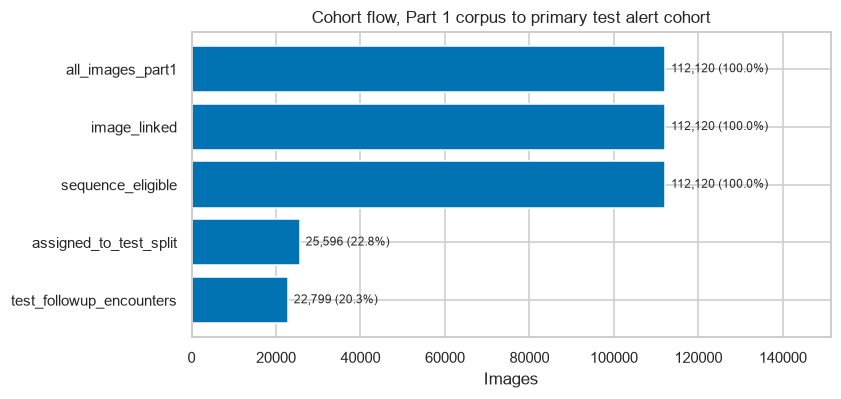

In [105]:
# ------------------------------ cohort flow -----------------------------------
COHORT_STEPS = [
    ("all_images_part1", len(wide)),
    ("image_linked", int(wide["image_exists"].sum())),
    ("sequence_eligible", int((wide["image_exists"] & wide["sequence_eligible"]).sum())),
    ("assigned_to_test_split",
     int(((wide["split"] == "test") & wide["sequence_eligible"]).sum())),
    ("test_followup_encounters",
     int(((wide["split"] == "test") & wide["sequence_eligible"]
          & ~wide["is_index_encounter"]).sum())),
]
cohort_flow = pd.DataFrame(COHORT_STEPS, columns=["step", "n_images"])
cohort_flow["n_patients"] = [
    wide["Patient ID"].nunique(),
    wide.loc[wide["image_exists"], "Patient ID"].nunique(),
    wide.loc[wide["image_exists"] & wide["sequence_eligible"], "Patient ID"].nunique(),
    wide.loc[(wide["split"] == "test") & wide["sequence_eligible"], "Patient ID"].nunique(),
    wide.loc[(wide["split"] == "test") & wide["sequence_eligible"]
             & ~wide["is_index_encounter"], "Patient ID"].nunique(),
]
cohort_flow["pct_of_start"] = (100 * cohort_flow["n_images"] /
                               cohort_flow["n_images"].iat[0]).round(3)
print(cohort_flow.to_string(index=False))
save_table(cohort_flow, "part2_cohort_flow")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(cohort_flow["step"][::-1], cohort_flow["n_images"][::-1], color=CB[0])
for y, (n, p) in enumerate(zip(cohort_flow["n_images"][::-1],
                               cohort_flow["pct_of_start"][::-1])):
    ax.text(n, y, f"  {n:,} ({p:.1f}%)", va="center", fontsize=8)
ax.set_xlabel("Images")
ax.set_title("Cohort flow, Part 1 corpus to primary test alert cohort")
ax.set_xlim(0, cohort_flow["n_images"].max() * 1.35)
save_figure(fig, "fig01_cohort_flow")
plt.show()

## 5. Select pathology targets and audit label prevalence

Selection uses training, validation and test **positive counts only**, never any model
output. Labels failing the minima are excluded with a stated reason and still saved, so
nothing is silently dropped. Meeting a numeric count threshold does not make two
pathologies clinically comparable, and the report should not be read that way.

         pathology  pos_train  pos_validation  pos_test  prev_train_pct  eligible   status             exclusion_reason
       Atelectasis       7640             640      3279          9.7618      True  primary                             
      Cardiomegaly       1542             165      1069          1.9703      True  primary                             
          Effusion       8092             567      4658         10.3394      True  primary                             
      Infiltration      12763            1019      6112         16.3076      True  primary                             
              Mass       3690             344      1748          4.7148      True  primary                             
            Nodule       4301             407      1623          5.4955      True  primary                             
         Pneumonia        790              86       555          1.0094      True  primary                             
      Pneumothorax       2427           

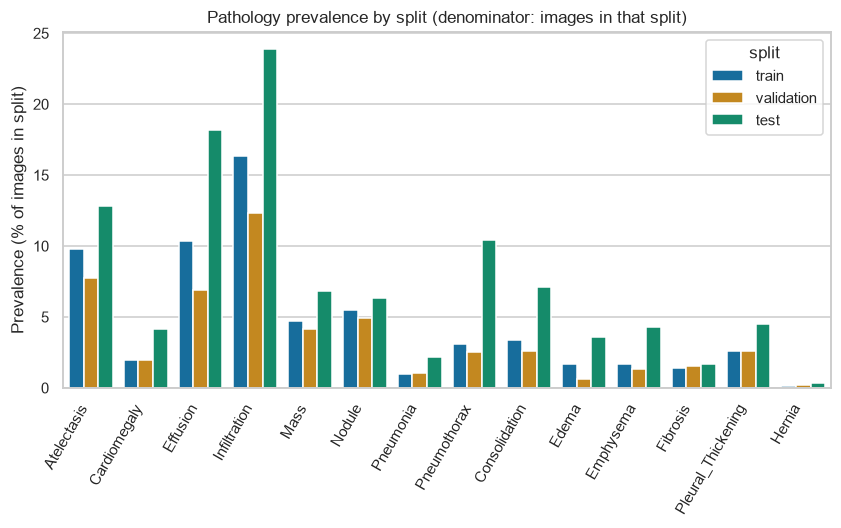

In [106]:
def select_eligible_pathologies(wide: pd.DataFrame) -> pd.DataFrame:
    """Report per-split positive counts and eligibility for every pathology."""
    rows = []
    for p in PATHOLOGIES:
        rec: Dict[str, object] = {"pathology": p}
        for split in ("train", "validation", "test"):
            d = wide[wide["split"] == split]
            rec[f"n_{split}"] = int(len(d))
            rec[f"pos_{split}"] = int(d[p].sum())
            rec[f"prev_{split}_pct"] = round(100 * float(d[p].mean()), 4) if len(d) else np.nan
        reasons = []
        if rec["pos_train"] < MIN_TRAIN_POSITIVES:
            reasons.append(f"train positives {rec['pos_train']} < {MIN_TRAIN_POSITIVES}")
        if rec["pos_validation"] < MIN_VALIDATION_POSITIVES:
            reasons.append(f"validation positives {rec['pos_validation']} "
                           f"< {MIN_VALIDATION_POSITIVES}")
        if rec["pos_test"] < MIN_TEST_POSITIVES:
            reasons.append(f"test positives {rec['pos_test']} < {MIN_TEST_POSITIVES}")
        rec["eligible"] = not reasons
        rec["exclusion_reason"] = "; ".join(reasons) if reasons else ""
        rows.append(rec)
    return pd.DataFrame(rows)


def make_label_selection_report(elig: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """Rank eligible labels by training prevalence and mark primary vs secondary."""
    out = elig.copy()
    qualified = out[out["eligible"]].sort_values("prev_train_pct", ascending=False)
    primary = qualified["pathology"].head(MAX_PRIMARY_LABELS).tolist()
    out["status"] = np.where(~out["eligible"], "excluded",
                             np.where(out["pathology"].isin(primary),
                                      "primary", "secondary_eligible_not_selected"))
    out["selection_rule"] = PRIMARY_LABEL_SELECTION_RULE
    out["max_primary_labels"] = MAX_PRIMARY_LABELS
    return out, primary


label_report, PRIMARY_LABELS = make_label_selection_report(
    select_eligible_pathologies(wide))
print(label_report[["pathology", "pos_train", "pos_validation", "pos_test",
                    "prev_train_pct", "eligible", "status", "exclusion_reason"]]
      .to_string(index=False))
save_table(label_report, "pathology_selection_report")
print(f"\nPrimary labels ({len(PRIMARY_LABELS)}): {PRIMARY_LABELS}")
_excluded = label_report.loc[~label_report["eligible"], "pathology"].tolist()
if _excluded:
    print(f"Excluded with stated reasons: {_excluded}")
_not_selected = label_report.loc[
    label_report["status"] == "secondary_eligible_not_selected", "pathology"].tolist()
if _not_selected:
    print(f"Eligible but beyond MAX_PRIMARY_LABELS: {_not_selected}")
print("\nCount thresholds are a statistical admissibility rule only. They say nothing "
      "about clinical comparability between these findings.")

fig, ax = plt.subplots(figsize=(9, 4.2))
melted = label_report.melt(id_vars="pathology",
                           value_vars=["prev_train_pct", "prev_validation_pct",
                                       "prev_test_pct"],
                           var_name="split", value_name="prevalence_pct")
melted["split"] = melted["split"].str.replace("prev_", "").str.replace("_pct", "")
sns.barplot(data=melted, x="pathology", y="prevalence_pct", hue="split", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Prevalence (% of images in split)")
ax.set_title("Pathology prevalence by split (denominator: images in that split)")
plt.xticks(rotation=60, ha="right")
save_figure(fig, "fig02_prevalence_by_split")
plt.show()

## 6. Load or build bounded image embeddings

The model is a linear head over frozen embeddings, so the backbone runs once. This is
the only expensive step in Part 2 and the only one that touches pixels.

**Hard rules.** A cache whose metadata says `pretrained_weights_used == False` is
rejected outright: random-weight vectors are meaningless and a cached file of them would
eventually be consumed as though it were real. The Part 1 demonstration cache (32
images) is likewise rejected for the main analysis. Extraction beyond 1,000 images
requires `ALLOW_FULL_CPU_EMBEDDING_EXTRACTION = True`, and a runtime estimate is printed
and must be acknowledged before anything starts.

Extraction is chunked, checkpointed and resumable: interrupt it and re-run the cell, and
it continues from the last completed chunk.

In [107]:
EMBED_PREPROCESSING_SPECS = {
    "resnet50_imagenet": "cxr-v1-gray3ch-224-imagenetnorm",
    "resnet18_imagenet": "cxr-v1-gray3ch-224-imagenetnorm",
    "densenet121_xrv_mimic_ch": "cxr-v2-gray1ch-224-xrvnorm",
    "densenet121_xrv_chex": "cxr-v2-gray1ch-224-xrvnorm",
}
EMBED_PREPROCESSING_VERSION = EMBED_PREPROCESSING_SPECS[PRIMARY_BACKBONE]
EMBED_CACHE_DIR = CACHE / f"embeddings_{PRIMARY_BACKBONE}"
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)
EMBED_META_PATH = EMBED_CACHE_DIR / "cache_metadata.json"
EMBED_IDS_PATH = EMBED_CACHE_DIR / "image_ids.parquet"
EMBED_ARRAY_PATH = EMBED_CACHE_DIR / "embeddings.npy"


def validate_embedding_cache(meta_path: Path = EMBED_META_PATH) -> Dict[str, object]:
    """Validate cache provenance. Raises on random weights or a demonstration-only cache."""
    if not meta_path.exists():
        return {"status": "absent", "n_images": 0}
    meta = json.loads(meta_path.read_text())
    if not meta.get("pretrained_weights_used", False):
        raise ValueError(
            f"Embedding cache at {meta_path.parent} was built without pretrained weights. "
            "Random-weight embeddings are never admissible. Delete the cache and rebuild "
            "with ALLOW_MODEL_DOWNLOAD = True.")
    if meta.get("backbone_id") != PRIMARY_BACKBONE:
        raise ValueError(f"Cache backbone {meta.get('backbone_id')!r} does not match "
                         f"PRIMARY_BACKBONE {PRIMARY_BACKBONE!r}.")
    if meta.get("preprocessing_version") != EMBED_PREPROCESSING_VERSION:
        raise ValueError(f"Cache preprocessing {meta.get('preprocessing_version')!r} does "
                         f"not match {EMBED_PREPROCESSING_VERSION!r}.")
    if meta.get("dataset_fingerprint") not in (None, P1_MANIFEST["dataset_fingerprint"]):
        warnings.warn("Embedding cache fingerprint differs from the Part 1 manifest.",
                      UserWarning)
    meta["status"] = "present"
    return meta


def load_embedding_cache() -> Tuple[Optional[np.ndarray], Optional[pd.Index], Dict]:
    """Memory-map the embedding array and return it with its aligned image-ID index."""
    meta = validate_embedding_cache()
    if meta["status"] == "absent" or not EMBED_ARRAY_PATH.exists():
        return None, None, meta
    ids = pd.read_parquet(EMBED_IDS_PATH)["Image Index"]
    arr = np.load(EMBED_ARRAY_PATH, mmap_mode="r")
    if len(ids) != arr.shape[0]:
        raise ValueError(f"Cache misalignment: {len(ids):,} ids vs {arr.shape[0]:,} rows.")
    if ids.duplicated().any():
        raise ValueError("Duplicate image IDs in the embedding cache.")
    meta.update({"n_images": int(arr.shape[0]), "embedding_dim": int(arr.shape[1])})
    return arr, pd.Index(ids), meta


def identify_missing_embeddings(needed: Sequence[str],
                                have: Optional[pd.Index]) -> List[str]:
    """Return image IDs required by the analysis that are absent from the cache."""
    if have is None:
        return list(needed)
    return sorted(set(needed) - set(have))


def load_backbone(name: str = PRIMARY_BACKBONE,
                  allow_download: bool = ALLOW_MODEL_DOWNLOAD):
    """Build the frozen CPU feature extractor. Refuses to construct random weights."""
    if not _TORCH:
        raise RuntimeError("PyTorch is required for embedding extraction.")
    import torch.nn as nn
    import torchvision
    if not allow_download:
        raise RuntimeError(
            "ALLOW_MODEL_DOWNLOAD is False, so pretrained weights cannot be obtained. "
            "Random-weight embeddings are never produced. Set ALLOW_MODEL_DOWNLOAD = True "
            "(one download, then cached by torchvision) or supply a local checkpoint.")
    if name == "resnet50_imagenet":
        m = torchvision.models.resnet50(
            weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Identity()
    elif name == "resnet18_imagenet":
        m = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Identity()
    elif name.startswith("densenet121_xrv_"):
        # Chest-radiograph pretrained. Deliberately NOT the 'all' or 'nih' weights:
        # those were trained on ChestX-ray14 and would have seen these test patients.
        import torchxrayvision as xrv
        tag = {"densenet121_xrv_mimic_ch": "densenet121-res224-mimic_ch",
               "densenet121_xrv_chex": "densenet121-res224-chex"}[name]
        base = xrv.models.DenseNet(weights=tag)

        class _XRVFeatures(nn.Module):
            """Wrap an XRV DenseNet so forward() returns the pooled 1024-d vector."""

            def __init__(self, net):
                super().__init__()
                self.net = net

            def forward(self, x):
                return self.net.features2(x)

        m = _XRVFeatures(base)
    else:
        raise ValueError(f"Unknown backbone {name!r}")
    m.eval()
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def torchvision_compose_xrv(size: int = EMBED_IMAGE_SIZE):
    """TorchXRayVision's own centre-crop then resize, applied to a (1, H, W) array."""
    import torchxrayvision as xrv
    crop, resize = xrv.datasets.XRayCenterCrop(), xrv.datasets.XRayResizer(size)
    return lambda a: resize(crop(a))

if _TORCH:
    from torch.utils.data import Dataset, DataLoader

    class EmbeddingDataset(Dataset):
        """Lazily decode radiographs using the preprocessing this backbone requires.

        ImageNet backbones take 3-channel tensors with ImageNet normalisation.
        TorchXRayVision backbones take 1 channel scaled to [-1024, 1024] with the
        library's own centre-crop and resize. Mixing them silently yields meaningless
        features, so the branch is keyed on the backbone name.
        """

        def __init__(self, paths: Sequence[str], size: int = EMBED_IMAGE_SIZE,
                     backbone: str = PRIMARY_BACKBONE) -> None:
            self.paths = list(paths)
            self.backbone = backbone
            self.is_xrv = backbone.startswith("densenet121_xrv_")
            self.channels = 1 if self.is_xrv else 3
            self.size = size
            if self.is_xrv:
                import torchxrayvision as xrv
                self.xrv_tf = torchvision_compose_xrv(size)
            else:
                from torchvision import transforms
                self.tf = transforms.Compose([
                    transforms.Resize((size, size)),
                    transforms.Grayscale(num_output_channels=3),
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                ])

        def __len__(self) -> int:
            return len(self.paths)

        def __getitem__(self, i: int):
            from PIL import Image
            try:
                if self.is_xrv:
                    import torchxrayvision as xrv
                    arr = np.asarray(Image.open(self.paths[i]).convert("L"),
                                     dtype=np.float32)
                    arr = xrv.datasets.normalize(arr, 255)      # -> [-1024, 1024]
                    arr = self.xrv_tf(arr[None, ...])           # (1, size, size)
                    return torch.from_numpy(arr.astype(np.float32)), i, True
                with Image.open(self.paths[i]) as im:
                    return self.tf(im.convert("L")), i, True
            except Exception:
                return torch.zeros(self.channels, self.size, self.size), i, False
else:
    EmbeddingDataset = None  # type: ignore


def estimate_extraction_runtime(n: int, backbone: str = PRIMARY_BACKBONE) -> float:
    """Print and return an estimated CPU runtime in hours for `n` images."""
    per_img = {"resnet50_imagenet": 0.06, "resnet18_imagenet": 0.02,
               "densenet121_xrv_mimic_ch": 0.06, "densenet121_xrv_chex": 0.06}.get(backbone, 0.10)
    hours = n * per_img / 3600
    print(f"[estimate] {backbone}: {n:,} images x ~{per_img:.2f} s/image "
          f"= ~{hours:.1f} h on a single-socket laptop CPU (highly machine-dependent).")
    return hours

def extract_missing_embeddings_resumable(
        missing: Sequence[str], path_lookup: pd.Series,
        chunk_size: int = EMBED_CHUNK_SIZE) -> int:
    """Extract embeddings for `missing` image IDs in resumable checkpointed chunks."""
    if not missing:
        print("  nothing to extract")
        return 0
    n = len(missing)
    if n > 1000 and not ALLOW_FULL_CPU_EMBEDDING_EXTRACTION:
        estimate_extraction_runtime(n)
        raise RuntimeError(
            f"{n:,} images require extraction but ALLOW_FULL_CPU_EMBEDDING_EXTRACTION is "
            "False. Read the runtime estimate above, then set that flag to True and "
            "re-run. Extraction is chunked and resumable, so it can be interrupted.")
    estimate_extraction_runtime(n)

    model = load_backbone()
    chunk_dir = EMBED_CACHE_DIR / "chunks"
    chunk_dir.mkdir(exist_ok=True)
    done = {p.stem for p in chunk_dir.glob("chunk_*.npz")}
    new_total, t0 = 0, time.perf_counter()

    for ci in range(0, n, chunk_size):
        tag = f"chunk_{ci:08d}"
        if tag in done:
            continue
        ids = list(missing[ci:ci + chunk_size])
        paths = [path_lookup[i] for i in ids]
        ds = EmbeddingDataset(paths)
        dl = DataLoader(ds, batch_size=32, num_workers=NUM_WORKERS, shuffle=False)
        vecs, oks = [], []
        with torch.no_grad():
            for xb, _idx, ok in dl:
                vecs.append(model(xb).numpy().astype(np.float32))
                oks.append(np.asarray(ok))
        np.savez_compressed(chunk_dir / f"{tag}.npz",
                            embeddings=np.concatenate(vecs, axis=0),
                            image_ids=np.array(ids, dtype=object),
                            ok=np.concatenate(oks, axis=0))
        new_total += len(ids)
        el = time.perf_counter() - t0
        rate = new_total / max(el, 1e-6)
        print(f"  {tag}: {new_total:,}/{n:,} done, {rate:.1f} img/s, "
              f"eta {(n - new_total)/max(rate,1e-6)/60:.1f} min")
    return new_total

def load_embedding_cache() -> Tuple[Optional[np.ndarray], Optional[pd.Index], Dict]:
    """Memory-map the embedding array and return it with its aligned image-ID index."""
    meta = validate_embedding_cache()
    if meta["status"] == "absent" or not EMBED_ARRAY_PATH.exists():
        return None, None, meta
    ids = pd.read_parquet(EMBED_IDS_PATH)["Image Index"]
    
    # Load as a regular array into RAM (or un-map memory) to avoid OS file locking
    arr = np.load(EMBED_ARRAY_PATH)
    
    if len(ids) != arr.shape[0]:
        raise ValueError(f"Cache misalignment: {len(ids):,} ids vs {arr.shape[0]:,} rows.")
    if ids.duplicated().any():
        raise ValueError("Duplicate image IDs in the embedding cache.")
    meta.update({"n_images": int(arr.shape[0]), "embedding_dim": int(arr.shape[1])})
    return arr, pd.Index(ids), meta


def merge_embedding_chunks(existing: Optional[np.ndarray],
                           existing_ids: Optional[pd.Index]) -> Tuple[np.ndarray, pd.Index]:
    """Merge checkpoint chunks into the consolidated cache array and clear the chunks."""
    chunk_dir = EMBED_CACHE_DIR / "chunks"
    chunks = sorted(chunk_dir.glob("chunk_*.npz")) if chunk_dir.exists() else []
    if not chunks:
        if existing is None:
            raise RuntimeError("No embeddings and no chunks to merge.")
        return np.asarray(existing), existing_ids

    arrs = [np.asarray(existing)] if existing is not None else []
    idss = [list(existing_ids)] if existing_ids is not None else []
    
    for c in chunks:
        with np.load(c, allow_pickle=True) as z:
            arrs.append(z["embeddings"].astype(np.float32))
            idss.append([str(x) for x in z["image_ids"]])

    arr = np.concatenate(arrs, axis=0)
    ids = pd.Index([i for sub in idss for i in sub], name="Image Index")
    keep = ~ids.duplicated()
    arr, ids = arr[keep.to_numpy() if hasattr(keep, "to_numpy") else keep], ids[keep]

    # Force Python to release open file locks before overwriting on Windows
    gc.collect()

    # Safely overwrite the target file
    if EMBED_ARRAY_PATH.exists():
        try:
            EMBED_ARRAY_PATH.unlink()
        except OSError:
            pass

    np.save(EMBED_ARRAY_PATH, arr)
    ids.to_frame(index=False).to_parquet(EMBED_IDS_PATH, index=False)
    
    EMBED_META_PATH.write_text(json.dumps({
        "backbone_id": PRIMARY_BACKBONE, "pretrained_weights_used": True,
        "preprocessing_version": EMBED_PREPROCESSING_VERSION,
        "embedding_dim": int(arr.shape[1]), "n_images": int(arr.shape[0]),
        "dataset_fingerprint": P1_MANIFEST["dataset_fingerprint"],
        "image_size": EMBED_IMAGE_SIZE, "random_seed": RANDOM_SEED,
        "created_utc": datetime.now(timezone.utc).isoformat(),
    }, indent=2))
    
    for c in chunks:
        try:
            c.unlink()
        except PermissionError:
            gc.collect()
            c.unlink(missing_ok=True)
            
    return arr, ids

# ------------------------- resolve the embedding matrix -----------------------
model_pool = wide[wide["image_exists"] & wide["sequence_eligible"]]
if FAST_MODE:
    rng = np.random.default_rng(RANDOM_SEED)
    keep_pts = {s: rng.choice(model_pool.loc[model_pool["split"] == s,
                                             "Patient ID"].unique(),
                              size=min(400, model_pool.loc[model_pool["split"] == s,
                                                           "Patient ID"].nunique()),
                              replace=False)
                for s in ("train", "validation", "test")}
    model_pool = model_pool[model_pool["Patient ID"].isin(
        np.concatenate(list(keep_pts.values())))]
    print(f"FAST_MODE: model pool reduced to {len(model_pool):,} images / "
          f"{model_pool['Patient ID'].nunique():,} patients (smoke test only)")

NEEDED_IDS = model_pool["Image Index"].tolist()
PATH_LOOKUP = wide.set_index("Image Index")["image_path"]

emb_arr, emb_ids, emb_meta = load_embedding_cache()
missing_ids = identify_missing_embeddings(NEEDED_IDS, emb_ids)
print(f"\nEmbedding cache status : {emb_meta.get('status')}")
print(f"Images needed          : {len(NEEDED_IDS):,}")
print(f"Already cached         : {len(NEEDED_IDS) - len(missing_ids):,}")
print(f"Missing                : {len(missing_ids):,}")

if missing_ids:
    if FAST_MODE and len(missing_ids) > EMBED_SMOKE_TEST_N:
        print(f"FAST_MODE: extracting only a deterministic {EMBED_SMOKE_TEST_N}-image subset")
        missing_ids = sorted(missing_ids)[:EMBED_SMOKE_TEST_N]
    extract_missing_embeddings_resumable(missing_ids, PATH_LOOKUP)
    emb_arr, emb_ids = merge_embedding_chunks(emb_arr, emb_ids)
    emb_arr, emb_ids, emb_meta = load_embedding_cache()

if emb_arr is None:
    raise RuntimeError("No embeddings available. See the extraction instructions above.")

EMB_POS = pd.Series(np.arange(len(emb_ids)), index=emb_ids)
covered = model_pool["Image Index"].isin(emb_ids)
if not covered.all():
    warnings.warn(f"{int((~covered).sum()):,} pool images lack embeddings and are dropped "
                  "from modelling. They remain in the Part 1 audit tables.", UserWarning)
    model_pool = model_pool[covered]

cache_audit = pd.DataFrame([
    ("backbone", emb_meta.get("backbone_id")),
    ("pretrained_weights_used", emb_meta.get("pretrained_weights_used")),
    ("preprocessing_version", emb_meta.get("preprocessing_version")),
    ("embedding_dim", emb_meta.get("embedding_dim")),
    ("n_images_cached", emb_meta.get("n_images")),
    ("n_images_needed", len(NEEDED_IDS)),
    ("n_images_covered", int(covered.sum())),
    ("duplicate_ids_in_cache", int(pd.Index(emb_ids).duplicated().sum())),
    ("fingerprint_matches_part1",
     emb_meta.get("dataset_fingerprint") == P1_MANIFEST["dataset_fingerprint"]),
], columns=["property", "value"])
print()
print(cache_audit.to_string(index=False))
save_table(cache_audit, "embedding_cache_audit")


Embedding cache status : present
Images needed          : 112,120
Already cached         : 112,120
Missing                : 0

                 property                      value
                 backbone   densenet121_xrv_mimic_ch
  pretrained_weights_used                       True
    preprocessing_version cxr-v2-gray1ch-224-xrvnorm
            embedding_dim                       1024
          n_images_cached                     112120
          n_images_needed                     112120
         n_images_covered                     112120
   duplicate_ids_in_cache                          0
fingerprint_matches_part1                       True
  table  -> embedding_cache_audit.csv  (9 x 2)


WindowsPath('C:/Users/kruta/Downloads/part2_outputs/full_densenet121_sens50/tables/embedding_cache_audit.csv')

**On the pretrained encoder.** The MIMIC-CXR-trained DenseNet is used only as a frozen
general chest-radiograph representation. It is not used as a zero-shot classifier, and its
source-dataset label ontology is not assumed equivalent to the ChestX-ray14 labels. The
study-specific linear head is trained exclusively on the NIH training split. No label
transfer between the two ontologies is claimed.

## 7. Train a lightweight multi-label image model

One linear layer over frozen embeddings, `BCEWithLogitsLoss` with capped positive class
weights computed on training data only, AdamW, early stopping on validation macro-AUPRC.
The backbone is not fine-tuned here.

**The model input is the embedding vector and nothing else.** No sequence position,
follow-up number, prior label, patient identifier, or alert-history variable enters the
feature matrix. That is asserted in code below, not merely intended, because it is the
assumption the entire post hoc burden simulation rests on.

In [108]:
from sklearn.metrics import roc_auc_score, average_precision_score

import torch.nn as nn
from torch.utils.data import TensorDataset


class EmbeddingLabelDataset(TensorDataset):
    """Paired frozen embeddings and multi-label targets. Features are embeddings only."""

    def __init__(self, X: np.ndarray, Y: np.ndarray) -> None:
        super().__init__(torch.from_numpy(np.ascontiguousarray(X, dtype=np.float32)),
                         torch.from_numpy(np.ascontiguousarray(Y, dtype=np.float32)))


class LinearMultiLabelHead(nn.Module):
    """Plain linear multi-label classifier over standardized frozen embeddings.

    Standardization is fitted on training data only and applied outside the module, so
    this is a genuine linear model with no batch-dependent state.
    """

    def __init__(self, in_dim: int, n_labels: int) -> None:
        super().__init__()
        self.fc = nn.Linear(in_dim, n_labels)

    def forward(self, x: "torch.Tensor") -> "torch.Tensor":
        return self.fc(x)


def fit_feature_standardizer(X_train: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Per-dimension mean and SD from training embeddings only."""
    mean = X_train.mean(axis=0, keepdims=True).astype(np.float32)
    sd = X_train.std(axis=0, keepdims=True).astype(np.float32)
    return mean, np.where(sd < 1e-6, 1.0, sd).astype(np.float32)


def apply_feature_standardizer(X: np.ndarray, mean: np.ndarray,
                               sd: np.ndarray) -> np.ndarray:
    """Apply the training-derived transform. Never refitted on validation or test."""
    return ((X.astype(np.float32) - mean) / sd).astype(np.float32)


def compute_positive_class_weights(Y_train: np.ndarray,
                                   cap: float = MAX_POS_WEIGHT) -> Tuple[np.ndarray, pd.DataFrame]:
    """Positive class weights (neg/pos) from training data only, capped and reported."""
    pos = Y_train.sum(axis=0)
    neg = Y_train.shape[0] - pos
    raw = np.where(pos > 0, neg / np.maximum(pos, 1), 1.0)
    capped = np.minimum(raw, cap)
    report = pd.DataFrame({
        "pathology": PRIMARY_LABELS,
        "n_positive_train": pos.astype(int),
        "raw_pos_weight": np.round(raw, 3),
        "applied_pos_weight": np.round(capped, 3),
        "weight_was_capped": raw > cap,
        "cap_value": cap,
    })
    return capped.astype(np.float32), report


def build_matrix(df_split: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Assemble the embedding matrix and label matrix for one split, aligned by row."""
    idx = EMB_POS.reindex(df_split["Image Index"]).to_numpy()
    if np.isnan(idx).any():
        raise ValueError("Some images in this split have no cached embedding.")
    X = np.asarray(emb_arr[idx.astype(int)], dtype=np.float32)
    Y = df_split[PRIMARY_LABELS].to_numpy().astype(np.float32)
    return X, Y, df_split.reset_index(drop=True)


splits = {s: model_pool[model_pool["split"] == s].copy()
          for s in ("train", "validation", "test")}
for s, d in splits.items():
    if d.empty:
        raise ValueError(f"Split {s!r} is empty after cohort restriction.")
Xtr, Ytr, dtr = build_matrix(splits["train"])
Xva, Yva, dva = build_matrix(splits["validation"])
Xte, Yte, dte = build_matrix(splits["test"])

# Standardization fitted on the training split only, then applied unchanged elsewhere.
X_MEAN, X_SD = fit_feature_standardizer(Xtr)
Xtr = apply_feature_standardizer(Xtr, X_MEAN, X_SD)
Xva = apply_feature_standardizer(Xva, X_MEAN, X_SD)
Xte = apply_feature_standardizer(Xte, X_MEAN, X_SD)
print(f"Feature standardizer fitted on {len(Xtr):,} training images only "
      f"({int((X_SD.ravel() < 1e-6).sum())} zero-variance dimensions guarded).")

# Assertion: the feature matrix is embeddings only, of the expected width.
assert Xtr.shape[1] == emb_meta["embedding_dim"], "feature width is not the embedding dim"
assert Xtr.shape[0] == len(dtr) and Xva.shape[0] == len(dva) and Xte.shape[0] == len(dte)
_forbidden = {"sequence_position_ordinal", "followup_number_numeric", "label_ever_prior",
              "label_prior_encounter", "Patient ID", "is_index_encounter"}
print("Feature-matrix isolation check: inputs are frozen embeddings only; none of "
      f"{sorted(_forbidden)} can reach the model by construction.")
print(f"train {Xtr.shape} | validation {Xva.shape} | test {Xte.shape}")

POS_W, weight_report = compute_positive_class_weights(Ytr)
print()
print(weight_report.to_string(index=False))

Feature standardizer fitted on 78,264 training images only (0 zero-variance dimensions guarded).
Feature-matrix isolation check: inputs are frozen embeddings only; none of ['Patient ID', 'followup_number_numeric', 'is_index_encounter', 'label_ever_prior', 'label_prior_encounter', 'sequence_position_ordinal'] can reach the model by construction.
train (78264, 1024) | validation (8260, 1024) | test (25596, 1024)

         pathology  n_positive_train  raw_pos_weight  applied_pos_weight  weight_was_capped  cap_value
      Infiltration             12763        5.132000            5.132000              False       20.0
          Effusion              8092        8.672000            8.672000              False       20.0
       Atelectasis              7640        9.244000            9.244000              False       20.0
            Nodule              4301       17.197001           17.197001              False       20.0
              Mass              3690       20.209999           20.0000

[start] train linear multi-label head
  epoch   1 | train 0.9921 | val 0.5840 | AUROC 0.6536 | AUPRC 0.0916  *
  epoch   2 | train 0.9310 | val 0.5265 | AUROC 0.6600 | AUPRC 0.0893
  epoch   3 | train 0.8984 | val 0.4923 | AUROC 0.6767 | AUPRC 0.0971  *
  epoch   4 | train 0.8769 | val 0.4561 | AUROC 0.6645 | AUPRC 0.0957
  epoch   5 | train 0.8641 | val 0.4412 | AUROC 0.6640 | AUPRC 0.0972  *
  epoch   6 | train 0.8535 | val 0.4241 | AUROC 0.6825 | AUPRC 0.0986  *
  epoch   7 | train 0.8463 | val 0.4085 | AUROC 0.6744 | AUPRC 0.1017  *
  epoch   8 | train 0.8418 | val 0.4078 | AUROC 0.6760 | AUPRC 0.0985
  epoch   9 | train 0.8375 | val 0.3990 | AUROC 0.6835 | AUPRC 0.0991
  epoch  10 | train 0.8339 | val 0.3998 | AUROC 0.6857 | AUPRC 0.1017  *
  epoch  11 | train 0.8327 | val 0.3896 | AUROC 0.6876 | AUPRC 0.0999
  epoch  12 | train 0.8291 | val 0.3874 | AUROC 0.6791 | AUPRC 0.0980
  epoch  13 | train 0.8277 | val 0.3856 | AUROC 0.6741 | AUPRC 0.0991
  epoch  14 | train 0.8268 | val 0

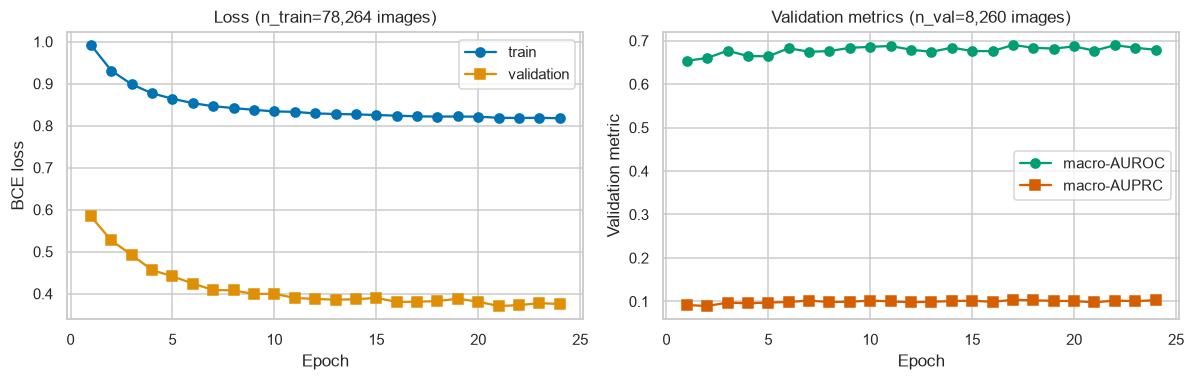

In [109]:
def safe_auroc(y: np.ndarray, p: np.ndarray) -> Tuple[float, str]:
    """AUROC, or NaN with a stated reason when undefined."""
    if len(np.unique(y)) < 2:
        return np.nan, "single class present"
    if len(y) < 10:
        return np.nan, "fewer than 10 observations"
    return float(roc_auc_score(y, p)), ""


def safe_auprc(y: np.ndarray, p: np.ndarray) -> Tuple[float, str]:
    """Average precision, or NaN with a stated reason when undefined."""
    if y.sum() == 0:
        return np.nan, "no positives"
    if len(np.unique(y)) < 2:
        return np.nan, "single class present"
    return float(average_precision_score(y, p)), ""


def predict_logits_and_probabilities(model: nn.Module, X: np.ndarray,
                                     batch_size: int = 1024
                                     ) -> Tuple[np.ndarray, np.ndarray]:
    """Batched logits and their sigmoid. Logits come from the model, never reconstructed."""
    model.eval()
    chunks = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(np.ascontiguousarray(X[i:i + batch_size],
                                                       dtype=np.float32))
            chunks.append(model(xb).cpu())
    if not chunks:
        empty = np.empty((0, len(PRIMARY_LABELS)), dtype=np.float32)
        return empty, empty
    logits = torch.cat(chunks, dim=0)
    return logits.numpy(), torch.sigmoid(logits).numpy()


def evaluate_logits(model: nn.Module, X: np.ndarray, Y: np.ndarray,
                    batch_size: int = 1024) -> Dict[str, object]:
    """Return probabilities, loss, macro-AUROC and macro-AUPRC for one split."""
    logits, probs = predict_logits_and_probabilities(model, X, batch_size)
    loss = float(nn.BCEWithLogitsLoss()(torch.from_numpy(logits),
                                        torch.from_numpy(Y.astype(np.float32))).item())
    aurocs = [safe_auroc(Y[:, j], probs[:, j])[0] for j in range(Y.shape[1])]
    auprcs = [safe_auprc(Y[:, j], probs[:, j])[0] for j in range(Y.shape[1])]
    return {"probs": probs, "loss": loss,
            "macro_auroc": float(np.nanmean(aurocs)) if np.any(~np.isnan(aurocs)) else np.nan,
            "macro_auprc": float(np.nanmean(auprcs)) if np.any(~np.isnan(auprcs)) else np.nan,
            "per_label_auroc": aurocs, "per_label_auprc": auprcs}


def predict_probabilities(model: nn.Module, X: np.ndarray,
                          batch_size: int = 1024) -> np.ndarray:
    """Batched probabilities via the shared direct-logit inference path."""
    return predict_logits_and_probabilities(model, X, batch_size)[1]


def save_checkpoint(model: nn.Module, path: Path, extra: Dict) -> Path:
    """Persist model weights plus the metadata needed to reload deterministically."""
    torch.save({"state_dict": model.state_dict(), "labels": PRIMARY_LABELS,
                "embedding_dim": int(emb_meta["embedding_dim"]),
                "feature_mean": X_MEAN, "feature_sd": X_SD,
                "backbone": PRIMARY_BACKBONE, "seed": RANDOM_SEED, **extra}, path)
    return path


def load_checkpoint(path: Path) -> Tuple[nn.Module, Dict]:
    """Reload a checkpoint into a fresh head."""
    ck = torch.load(path, map_location="cpu", weights_only=False)
    m = LinearMultiLabelHead(ck["embedding_dim"], len(ck["labels"]))
    m.load_state_dict(ck["state_dict"])
    m.eval()
    return m, ck


def train_multilabel_model(Xtr, Ytr, Xva, Yva, pos_weight: np.ndarray
                           ) -> Tuple[nn.Module, pd.DataFrame]:
    """Train the linear head with early stopping on validation macro-AUPRC.

    The test split is never touched inside this function.
    """
    torch.manual_seed(RANDOM_SEED)
    max_epochs = 3 if FAST_MODE else MAX_EPOCHS
    patience = 2 if FAST_MODE else EARLY_STOPPING_PATIENCE

    model = LinearMultiLabelHead(Xtr.shape[1], len(PRIMARY_LABELS))
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                            weight_decay=WEIGHT_DECAY)
    lossfn = nn.BCEWithLogitsLoss(pos_weight=torch.from_numpy(pos_weight))
    dl = torch.utils.data.DataLoader(EmbeddingLabelDataset(Xtr, Ytr),
                                     batch_size=BATCH_SIZE, shuffle=True,
                                     num_workers=NUM_WORKERS)

    best, best_epoch, wait, hist = -np.inf, -1, 0, []
    ckpt = LOGS / "best_head.pt"
    t0 = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        tot, nb = 0.0, 0
        for xb, yb in dl:
            opt.zero_grad()
            loss = lossfn(model(xb), yb)
            loss.backward()
            opt.step()
            tot += float(loss.item())
            nb += 1
        ev = evaluate_logits(model, Xva, Yva)
        improved = ev["macro_auprc"] > best + 1e-6
        if improved:
            best, best_epoch, wait = ev["macro_auprc"], epoch, 0
            save_checkpoint(model, ckpt, {"epoch": epoch,
                                          "val_macro_auprc": ev["macro_auprc"]})
        else:
            wait += 1
        hist.append({"epoch": epoch, "train_loss": tot / max(nb, 1),
                     "val_loss": ev["loss"], "val_macro_auroc": ev["macro_auroc"],
                     "val_macro_auprc": ev["macro_auprc"],
                     "improved": improved, "patience_counter": wait,
                     "elapsed_s": round(time.perf_counter() - t0, 2)})
        print(f"  epoch {epoch:>3} | train {tot/max(nb,1):.4f} | val {ev['loss']:.4f} "
              f"| AUROC {ev['macro_auroc']:.4f} | AUPRC {ev['macro_auprc']:.4f}"
              f"{'  *' if improved else ''}")
        if wait >= patience:
            print(f"  early stopping at epoch {epoch}; best was epoch {best_epoch}")
            break

    model, _ = load_checkpoint(ckpt)
    return model, pd.DataFrame(hist)


with timed("train linear multi-label head"):
    MODEL, history = train_multilabel_model(Xtr, Ytr, Xva, Yva, POS_W)
save_table(history, "training_history")
save_table(weight_report, "positive_class_weight_report")
print(f"\nCheckpoint: {LOGS / 'best_head.pt'}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train", color=CB[0])
axes[0].plot(history["epoch"], history["val_loss"], marker="s", label="validation", color=CB[1])
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend()
axes[0].set_title(f"Loss (n_train={len(Xtr):,} images)")
axes[1].plot(history["epoch"], history["val_macro_auroc"], marker="o",
             label="macro-AUROC", color=CB[2])
axes[1].plot(history["epoch"], history["val_macro_auprc"], marker="s",
             label="macro-AUPRC", color=CB[3])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation metric"); axes[1].legend()
axes[1].set_title(f"Validation metrics (n_val={len(Xva):,} images)")
fig.tight_layout()
save_figure(fig, "fig03_training_curves")
plt.show()

## 8. Select thresholds using validation data only

Pathology-specific thresholds maximise validation F1 subject to validation sensitivity
at or above `MIN_VALIDATION_SENSITIVITY`. When no grid point satisfies the floor, the
threshold achieving the highest sensitivity is taken and the fallback is recorded
per pathology rather than buried.

Thresholds are written to disk **before** section 9 computes any test quantity. A fixed
0.50 threshold is carried as a labelled sensitivity analysis only.

In [110]:
def threshold_grid_search(y: np.ndarray, p: np.ndarray,
                          grid: np.ndarray) -> pd.DataFrame:
    """Vectorised sensitivity/specificity/PPV/F1 across a threshold grid."""
    y = y.astype(bool)
    fires = p[None, :] >= grid[:, None]
    tp = (fires & y[None, :]).sum(axis=1)
    fp = (fires & ~y[None, :]).sum(axis=1)
    fn = (~fires & y[None, :]).sum(axis=1)
    tn = (~fires & ~y[None, :]).sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        sens = np.where(tp + fn > 0, tp / (tp + fn), np.nan)
        spec = np.where(tn + fp > 0, tn / (tn + fp), np.nan)
        ppv = np.where(tp + fp > 0, tp / (tp + fp), np.nan)
        f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / (2 * tp + fp + fn), np.nan)
    return pd.DataFrame({"threshold": grid, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                         "sensitivity": sens, "specificity": spec, "ppv": ppv, "f1": f1,
                         "alert_rate": fires.mean(axis=1)})


def select_validation_thresholds(Yva: np.ndarray, Pva: np.ndarray
                                 ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Choose one threshold per pathology on validation data; return grid and selections."""
    grid = np.round(np.arange(0.01, 1.00, 0.01), 3)
    all_rows, chosen = [], []
    for j, path in enumerate(PRIMARY_LABELS):
        g = threshold_grid_search(Yva[:, j], Pva[:, j], grid)
        g.insert(0, "pathology", path)
        all_rows.append(g)

        ok = g[g["sensitivity"] >= MIN_VALIDATION_SENSITIVITY]
        if len(ok) and ok["f1"].notna().any():
            row = ok.loc[ok["f1"].idxmax()]
            rule, fallback = PRIMARY_THRESHOLD_RULE, False
        else:
            row = g.loc[g["sensitivity"].idxmax()]
            rule, fallback = "fallback_max_validation_sensitivity", True
        chosen.append({
            "pathology": path, "threshold": float(row["threshold"]),
            "rule_applied": rule, "fallback_used": fallback,
            "val_sensitivity": round(float(row["sensitivity"]), 4),
            "val_specificity": round(float(row["specificity"]), 4),
            "val_ppv": round(float(row["ppv"]), 4) if pd.notna(row["ppv"]) else np.nan,
            "val_f1": round(float(row["f1"]), 4) if pd.notna(row["f1"]) else np.nan,
            "val_alert_rate": round(float(row["alert_rate"]), 4),
            "sensitivity_floor": MIN_VALIDATION_SENSITIVITY,
            "selected_on": "validation_split_only",
        })
    return pd.concat(all_rows, ignore_index=True), pd.DataFrame(chosen)


def validate_threshold_selection(sel: pd.DataFrame) -> None:
    """Assert thresholds are in range, complete, and derived from validation data only."""
    if len(sel) != len(PRIMARY_LABELS):
        raise ValueError("One threshold per primary label is required.")
    if not sel["threshold"].between(0, 1).all():
        raise ValueError("Threshold outside [0, 1].")
    if not (sel["selected_on"] == "validation_split_only").all():
        raise ValueError("A threshold was not derived from validation data only.")
    n_fb = int(sel["fallback_used"].sum())
    if n_fb:
        warnings.warn(f"{n_fb} of {len(sel)} pathologies could not reach the validation "
                      f"sensitivity floor of {MIN_VALIDATION_SENSITIVITY}. The "
                      "highest-sensitivity threshold was used and is flagged per row.",
                      UserWarning)


Pva = predict_probabilities(MODEL, Xva)
val_grid, THRESHOLDS = select_validation_thresholds(Yva, Pva)
validate_threshold_selection(THRESHOLDS)
save_table(val_grid, "validation_threshold_grid")
save_table(THRESHOLDS, "selected_thresholds")

val_metrics = []
for j, path in enumerate(PRIMARY_LABELS):
    au, ar = safe_auroc(Yva[:, j], Pva[:, j])
    ap, pr = safe_auprc(Yva[:, j], Pva[:, j])
    val_metrics.append({"split": "validation", "pathology": path, "n_images": len(Yva),
                        "n_positive": int(Yva[:, j].sum()),
                        "n_negative": int((Yva[:, j] == 0).sum()),
                        "prevalence_pct": round(100 * float(Yva[:, j].mean()), 4),
                        "auroc": au, "auroc_undefined_reason": ar,
                        "auprc": ap, "auprc_undefined_reason": pr,
                        "calibration_evaluated": False})
val_metrics = pd.DataFrame(val_metrics)
save_table(val_metrics, "validation_metrics")

print()
print(THRESHOLDS[["pathology", "threshold", "val_sensitivity", "val_ppv", "val_f1",
                  "val_alert_rate", "fallback_used"]].to_string(index=False))
print("\nThresholds are now LOCKED. No test quantity has been computed at this point.")
THRESH_MAP = dict(zip(THRESHOLDS["pathology"], THRESHOLDS["threshold"]))

  table  -> validation_threshold_grid.csv  (1,287 x 11)
  table  -> selected_thresholds.csv  (13 x 11)
  table  -> validation_metrics.csv  (13 x 11)

         pathology  threshold  val_sensitivity  val_ppv  val_f1  val_alert_rate  fallback_used
      Infiltration       0.43           0.6928   0.1585  0.2579          0.5393          False
          Effusion       0.63           0.5273   0.3981  0.4537          0.0909          False
       Atelectasis       0.52           0.5219   0.1532  0.2369          0.2639          False
            Nodule       0.50           0.5602   0.0703  0.1249          0.3926          False
              Mass       0.51           0.5000   0.0764  0.1326          0.2725          False
     Consolidation       0.30           0.5231   0.0453  0.0834          0.3021          False
      Pneumothorax       0.30           0.5381   0.0368  0.0688          0.3720          False
Pleural_Thickening       0.31           0.5395   0.0411  0.0763          0.3419          F

## 9. Generate frozen held-out predictions and image-level metrics

Test probabilities are generated once and written to disk in long format, one row per
image-pathology pair. Everything downstream reads that frozen file.

  table  -> test_image_level_metrics.csv  (13 x 31)
         pathology  n_positive  prevalence_pct    auroc    auprc  sel_threshold  sel_sensitivity  sel_ppv  sel_alert_rate
      Infiltration        6112         23.8787 0.622511 0.332988           0.43         0.887762 0.260540        0.813643
          Effusion        4658         18.1982 0.738688 0.369078           0.63         0.634822 0.321343        0.359509
       Atelectasis        3279         12.8106 0.660927 0.216933           0.52         0.781336 0.169444        0.590717
            Nodule        1623          6.3408 0.588638 0.092006           0.50         0.594578 0.078062        0.482966
              Mass        1748          6.8292 0.617641 0.108893           0.51         0.634439 0.089177        0.485857
     Consolidation        1815          7.0910 0.678210 0.114723           0.30         0.934435 0.088884        0.745468
      Pneumothorax        2665         10.4118 0.722282 0.223074           0.30         0.8682

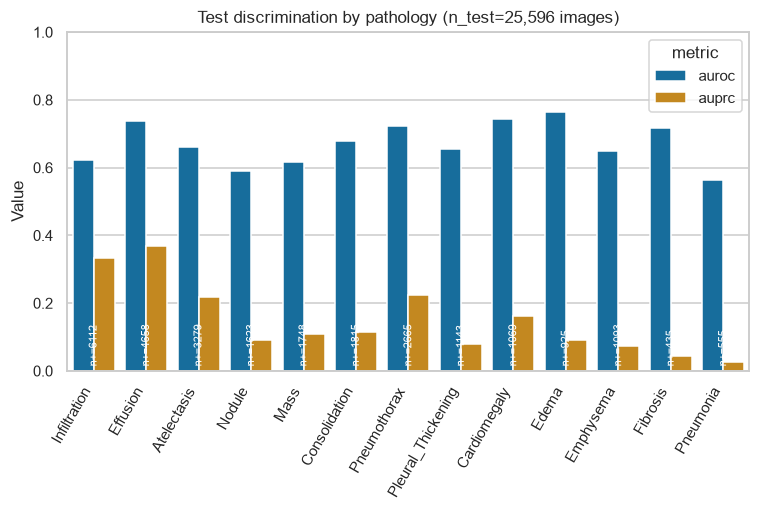

In [111]:
def calculate_threshold_metrics(y: np.ndarray, p: np.ndarray,
                                t: float) -> Dict[str, object]:
    """Confusion counts and operating-point metrics at a fixed threshold."""
    fires = p >= t
    yb = y.astype(bool)
    tp, fp = int((fires & yb).sum()), int((fires & ~yb).sum())
    fn, tn = int((~fires & yb).sum()), int((~fires & ~yb).sum())
    d = lambda a, b: (a / b) if b else np.nan
    return {"threshold": t, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "sensitivity": d(tp, tp + fn), "specificity": d(tn, tn + fp),
            "ppv": d(tp, tp + fp), "npv": d(tn, tn + fn),
            "alert_rate": float(fires.mean())}


Pte = predict_probabilities(MODEL, Xte)

test_metrics = []
for j, path in enumerate(PRIMARY_LABELS):
    au, ar = safe_auroc(Yte[:, j], Pte[:, j])
    ap, pr = safe_auprc(Yte[:, j], Pte[:, j])
    rec = {"split": "test", "pathology": path, "n_images": len(Yte),
           "n_positive": int(Yte[:, j].sum()), "n_negative": int((Yte[:, j] == 0).sum()),
           "prevalence_pct": round(100 * float(Yte[:, j].mean()), 4),
           "auroc": au, "auroc_undefined_reason": ar,
           "auprc": ap, "auprc_undefined_reason": pr,
           "calibration_evaluated": False}
    rec.update({f"sel_{k}": v for k, v in
                calculate_threshold_metrics(Yte[:, j], Pte[:, j], THRESH_MAP[path]).items()})
    rec.update({f"fixed50_{k}": v for k, v in
                calculate_threshold_metrics(Yte[:, j], Pte[:, j],
                                            FIXED_THRESHOLD_SENSITIVITY_VALUE).items()})
    test_metrics.append(rec)
test_metrics = pd.DataFrame(test_metrics)
save_table(test_metrics, "test_image_level_metrics")
print(test_metrics[["pathology", "n_positive", "prevalence_pct", "auroc", "auprc",
                    "sel_threshold", "sel_sensitivity", "sel_ppv",
                    "sel_alert_rate"]].to_string(index=False))

CARRY = ["Image Index", "Patient ID", "split", "sequence_position_ordinal",
         "patient_sequence_length", "is_index_encounter", "sequence_eligible",
         "sequence_eligible_metadata", "strict_history_eligible", "age_consistent",
         "age_grossly_inconsistent", "sex_group", "age_band", "projection_group"]

prob_df = pd.DataFrame(Pte, columns=PRIMARY_LABELS)
prob_df[CARRY] = dte[CARRY].reset_index(drop=True)
label_df = pd.DataFrame(Yte.astype(np.int8), columns=PRIMARY_LABELS)
label_df["Image Index"] = dte["Image Index"].values

test_pred_long = (prob_df.melt(id_vars=CARRY, value_vars=PRIMARY_LABELS,
                               var_name="pathology", value_name="probability")
                  .merge(label_df.melt(id_vars="Image Index", value_vars=PRIMARY_LABELS,
                                       var_name="pathology", value_name="label_current"),
                         on=["Image Index", "pathology"], how="left", validate="1:1"))
test_pred_long["threshold"] = test_pred_long["pathology"].map(THRESH_MAP)
if test_pred_long.duplicated(["Image Index", "pathology"]).any():
    raise ValueError("Duplicate (Image Index, pathology) rows in test predictions.")
if test_pred_long[["probability", "label_current", "threshold"]].isna().any().any():
    raise ValueError("Null probability, label, or threshold in test predictions.")

test_pred_long.to_parquet(TABLES / "test_predictions_long.parquet", index=False)
_SAVED_TABLES.append("test_predictions_long.parquet")
print(f"\nFrozen test predictions: {len(test_pred_long):,} image-pathology rows "
      f"({test_pred_long['Image Index'].nunique():,} images, "
      f"{test_pred_long['Patient ID'].nunique():,} patients)")

fig, ax = plt.subplots(figsize=(8, 4))
m = test_metrics.melt(id_vars="pathology", value_vars=["auroc", "auprc"],
                      var_name="metric", value_name="value")
sns.barplot(data=m, x="pathology", y="value", hue="metric", ax=ax)
for j, p in enumerate(test_metrics["pathology"]):
    ax.text(j, 0.02, f"n+={int(test_metrics.loc[j,'n_positive'])}", ha="center",
            fontsize=7, rotation=90, color="white")
ax.set_ylim(0, 1); ax.set_xlabel(""); ax.set_ylabel("Value")
ax.set_title(f"Test discrimination by pathology (n_test={len(Yte):,} images)")
plt.xticks(rotation=60, ha="right")
save_figure(fig, "fig04_test_discrimination")
plt.show()

## 10. Construct the simulated serial alert stream

### 10.1 History isolation, enforced by recomputation

Part 1's history columns were derived over each patient's **full** sequence. They are
deliberately not reused here. Both label history and prediction history are recomputed
from scratch **within the test split**, so no training or validation encounter can enter
a test-side history window. Under a patient-disjoint split the two agree; recomputing
makes the guarantee structural rather than contingent.

### 10.2 The warm-up rule, pre-specified

A patient's earliest test-split encounter has no earlier test-split history and must not
be classified as first-observed on that basis. `is_test_sequence_warmup_encounter` marks
it. **Warm-up encounters are excluded from the primary decomposition**, their count is
reported, and an including sensitivity analysis is run.

Note what happens under a patient-disjoint split: a patient's whole sequence sits in one
split, so the warm-up encounter *is* the index encounter and is already excluded. The
audit below reports the overlap, so the rule is verified to be a no-op rather than
assumed to be one.

In [112]:
def add_prediction_history(stream: pd.DataFrame) -> pd.DataFrame:
    """Derive within-split label and prediction history along the ordinal sequence."""
    d = stream.sort_values(["Patient ID", "pathology", "sequence_position_ordinal",
                            "Image Index"], kind="mergesort").copy()
    d["model_fires"] = (d["probability"] >= d["threshold"]).astype("int8")

    grp = d.groupby(["Patient ID", "pathology"], observed=True, sort=False)
    lab, fir = grp["label_current"], grp["model_fires"]

    d["label_prior_encounter"] = lab.shift(1)
    d["n_label_prior_positive"] = (lab.cumsum() - d["label_current"]).astype("int32")
    d["label_ever_prior"] = d["n_label_prior_positive"] > 0

    d["fired_prior_encounter"] = fir.shift(1)
    d["prior_probability"] = grp["probability"].shift(1)
    d["n_fired_prior"] = (fir.cumsum() - d["model_fires"]).astype("int32")
    d["fired_ever_prior"] = d["n_fired_prior"] > 0

    first_pos = grp["sequence_position_ordinal"].transform("min")
    d["is_test_sequence_warmup_encounter"] = (
        d["sequence_position_ordinal"] == first_pos)
    return d


def assert_test_history_isolation(stream: pd.DataFrame, wide: pd.DataFrame) -> Dict:
    """Verify no history window can draw on a non-test encounter."""
    if not (stream["split"] == "test").all():
        raise ValueError("The alert stream contains non-test rows.")
    test_pts = set(stream["Patient ID"].unique())
    leaked = wide[(wide["Patient ID"].isin(test_pts)) & (wide["split"] != "test")]
    n_leak = int(leaked["Image Index"].nunique())
    if n_leak:
        warnings.warn(
            f"{n_leak:,} images from {leaked['Patient ID'].nunique():,} test patients sit "
            "in train/validation. History is recomputed within the test split, so those "
            "encounters cannot enter a history window, but the patient's observed "
            "sequence is fragmented and warm-up handling matters.", UserWarning)
    return {"test_patients": len(test_pts),
            "test_patient_images_outside_test_split": n_leak,
            "sequence_fragmented": n_leak > 0}


def build_test_alert_stream(pred_long: pd.DataFrame, wide: pd.DataFrame
                            ) -> Tuple[pd.DataFrame, Dict, pd.DataFrame]:
    """Assemble the primary held-out alert stream with pre-specified exclusions."""
    base = pred_long[(pred_long["split"] == "test")
                     & (pred_long["sequence_eligible"])].copy()
    iso = assert_test_history_isolation(base, wide)
    stream = add_prediction_history(base)

    n_all = len(stream)
    n_index = int(stream["is_index_encounter"].sum())
    n_warm = int(stream["is_test_sequence_warmup_encounter"].sum())
    n_both = int((stream["is_index_encounter"]
                  & stream["is_test_sequence_warmup_encounter"]).sum())
    n_warm_only = int((stream["is_test_sequence_warmup_encounter"]
                       & ~stream["is_index_encounter"]).sum())

    stream["in_primary_cohort"] = (~stream["is_index_encounter"]
                                   & ~stream["is_test_sequence_warmup_encounter"])
    audit = pd.DataFrame([
        ("test_eligible_image_pathology_rows", n_all),
        ("index_encounter_rows_excluded", n_index),
        ("warmup_encounter_rows", n_warm),
        ("rows_both_index_and_warmup", n_both),
        ("warmup_rows_not_already_index", n_warm_only),
        ("primary_cohort_rows", int(stream["in_primary_cohort"].sum())),
        ("primary_cohort_images",
         int(stream.loc[stream["in_primary_cohort"], "Image Index"].nunique())),
        ("primary_cohort_patients",
         int(stream.loc[stream["in_primary_cohort"], "Patient ID"].nunique())),
        ("warmup_rule_is_noop_under_this_split", n_warm_only == 0),
    ], columns=["metric", "value"])
    return stream, iso, audit


with timed("build held-out alert stream"):
    STREAM, ISO, warm_audit = build_test_alert_stream(test_pred_long, wide)
print()
print(warm_audit.to_string(index=False))
save_table(warm_audit, "test_warmup_encounter_audit")
STREAM.to_parquet(TABLES / "test_alert_stream.parquet", index=False)
_SAVED_TABLES.append("test_alert_stream.parquet")

if bool(warm_audit.loc[warm_audit["metric"] ==
                       "warmup_rule_is_noop_under_this_split", "value"].iat[0]):
    print("\nEvery warm-up encounter is also an index encounter, so the warm-up rule "
          "removes nothing beyond the index exclusion. That is the expected result under "
          "a patient-disjoint split, and it is now verified rather than assumed.")
else:
    print("\nWarm-up encounters exist that are not index encounters: the test split "
          "fragments some patient sequences. They are excluded from the primary cohort "
          "and a sensitivity analysis including them is reported in section 11.")

[start] build held-out alert stream
[done ] build held-out alert stream (0.3 s)

                              metric  value
  test_eligible_image_pathology_rows 332748
       index_encounter_rows_excluded  36361
               warmup_encounter_rows  36361
          rows_both_index_and_warmup  36361
       warmup_rows_not_already_index      0
                 primary_cohort_rows 296387
               primary_cohort_images  22799
             primary_cohort_patients   1424
warmup_rule_is_noop_under_this_split   True
  table  -> test_warmup_encounter_audit.csv  (9 x 2)

Every warm-up encounter is also an index encounter, so the warm-up rule removes nothing beyond the index exclusion. That is the expected result under a patient-disjoint split, and it is now verified rather than assumed.


## 11. Decompose burden using label-history and prediction-history definitions

### 11.1 The two families

**Label history** asks whether the pathology was positive earlier in the available
sequence. It is a retrospective, oracle-like measurement: a deployed system cannot
consult reference labels.

**Prediction history** asks whether the model itself fired earlier for that
patient-pathology pair at the same threshold. This is what a real suppression rule could
actually condition on.

The difference between them is the observed mismatch between prior positive-label
history and prior model-alert history in the available sequence. It arises from model
sensitivity, threshold choice, weak-label instability, and incomplete observed history
together, and must not be attributed to any one of those.

The two families are reported side by side and never combined into a single number.

### 11.2 Categories

Every eligible non-warm-up image-pathology pair receives exactly one of `false_alert`,
`redundant_alert`, `first_observed_positive_alert`, `missed_positive`, `true_silence`.
Mutual exclusivity and exhaustiveness are asserted in code.

In [113]:
REDUNDANCY_PREDICATES: Tuple[str, ...] = (
    "label_historical", "label_immediate_prior",
    "prediction_historical", "prediction_immediate_prior",
)
ALERT_CATEGORIES: Tuple[str, ...] = (
    "false_alert", "redundant_alert", "first_observed_positive_alert",
    "missed_positive", "true_silence",
)
FIRED_CATEGORIES = ALERT_CATEGORIES[:3]


@dataclass(frozen=True)
class BurdenSpec:
    """Frozen specification of one burden computation."""
    redundancy_definition: str
    cohort: str = PRIMARY_ALERT_COHORT
    include_warmup: bool = False
    strict_cohort: bool = False
    age_consistent_only: bool = False
    fires_col: str = "model_fires"
    label_col: str = "label_current"

    def __post_init__(self) -> None:
        if self.redundancy_definition not in REDUNDANCY_PREDICATES:
            raise ValueError(f"redundancy_definition must be one of "
                             f"{REDUNDANCY_PREDICATES}, got {self.redundancy_definition!r}")


def _cohort(stream: pd.DataFrame, spec: BurdenSpec) -> pd.DataFrame:
    """Apply the cohort filters implied by `spec`."""
    d = stream[~stream["is_index_encounter"]]
    if not spec.include_warmup:
        d = d[~d["is_test_sequence_warmup_encounter"]]
    if spec.strict_cohort:
        d = d[d["strict_history_eligible"]]
    if spec.age_consistent_only:
        d = d[d["age_consistent"]]
    return d.copy()


def classify_alert_burden(stream: pd.DataFrame, spec: BurdenSpec) -> pd.DataFrame:
    """Assign exactly one mutually exclusive alert-burden category per row."""
    d = _cohort(stream, spec)
    predicate = {
        "label_historical": d["label_ever_prior"].fillna(False).astype(bool),
        "label_immediate_prior": d["label_prior_encounter"].eq(1),
        "prediction_historical": d["fired_ever_prior"].fillna(False).astype(bool),
        "prediction_immediate_prior": d["fired_prior_encounter"].eq(1),
    }[spec.redundancy_definition]

    fires = d[spec.fires_col] == 1
    pos = d[spec.label_col] == 1
    d["alert_category"] = np.select(
        [fires & ~pos, fires & pos & predicate, fires & pos & ~predicate, ~fires & pos],
        list(FIRED_CATEGORIES) + ["missed_positive"], default="true_silence")
    d["redundancy_definition"] = spec.redundancy_definition
    d["history_family"] = ("label_history" if spec.redundancy_definition.startswith("label")
                           else "prediction_history")
    return d


def assert_mutually_exclusive_alert_categories(classified: pd.DataFrame,
                                               n_expected: int) -> None:
    """Assert one category per row, all recognised, none missing."""
    vc = classified["alert_category"].value_counts()
    unknown = set(vc.index) - set(ALERT_CATEGORIES)
    if unknown:
        raise ValueError(f"Unrecognised alert categories: {sorted(unknown)}")
    if int(vc.sum()) != n_expected or classified["alert_category"].isna().any():
        raise ValueError(f"Category assignment covers {int(vc.sum()):,} of "
                         f"{n_expected:,} rows; assignment must be exhaustive.")


def summarize_alert_burden(classified: pd.DataFrame, spec: BurdenSpec) -> pd.DataFrame:
    """Aggregate a classified stream into the three pre-specified denominators."""
    n_img = classified["Image Index"].nunique()
    n_pt = classified["Patient ID"].nunique()
    n_opp = len(classified)
    counts = classified["alert_category"].value_counts()
    fired = int(sum(counts.get(c, 0) for c in FIRED_CATEGORIES))

    per_pt = (classified[classified["alert_category"].isin(FIRED_CATEGORIES)]
              .groupby("Patient ID").size().reindex(classified["Patient ID"].unique(),
                                                    fill_value=0))
    rows = []
    for cat in ALERT_CATEGORIES:
        n = int(counts.get(cat, 0))
        rows.append({
            "redundancy_definition": spec.redundancy_definition,
            "history_family": ("label_history"
                               if spec.redundancy_definition.startswith("label")
                               else "prediction_history"),
            "cohort": spec.cohort, "include_warmup": spec.include_warmup,
            "strict_cohort": spec.strict_cohort,
            "age_consistent_only": spec.age_consistent_only,
            "alert_category": cat, "n": n,
            "per_100_followup_images": round(100 * n / n_img, 3) if n_img else np.nan,
            "per_patient": round(n / n_pt, 4) if n_pt else np.nan,
            "per_100_patient_pathology_opportunities":
                round(100 * n / n_opp, 4) if n_opp else np.nan,
            "share_of_fired_alerts_pct": (round(100 * n / fired, 3)
                                          if fired and cat in FIRED_CATEGORIES else np.nan),
        })
    out = pd.DataFrame(rows)
    out["n_followup_images"] = n_img
    out["n_patients"] = n_pt
    out["n_patient_pathology_opportunities"] = n_opp
    out["total_fired_alerts"] = fired
    out["median_fired_alerts_per_patient"] = float(per_pt.median()) if len(per_pt) else np.nan
    out["iqr_fired_alerts_per_patient"] = (
        f"{per_pt.quantile(.25):.1f}-{per_pt.quantile(.75):.1f}" if len(per_pt) else "")
    return out


# ---------------------------- primary + secondary -----------------------------
SPEC_PRIMARY = BurdenSpec(PRIMARY_REDUNDANCY_DEFINITION)
SPEC_SECONDARY = BurdenSpec(SECONDARY_REDUNDANCY_DEFINITION)

CLS_LABEL = classify_alert_burden(STREAM, SPEC_PRIMARY)
CLS_PRED = classify_alert_burden(STREAM, SPEC_SECONDARY)
for c in (CLS_LABEL, CLS_PRED):
    assert_mutually_exclusive_alert_categories(c, len(c))

burden_label = summarize_alert_burden(CLS_LABEL, SPEC_PRIMARY)
burden_pred = summarize_alert_burden(CLS_PRED, SPEC_SECONDARY)
save_table(burden_label, "primary_alert_burden_label_history")
save_table(burden_pred, "primary_alert_burden_prediction_history")

show = ["alert_category", "n", "per_100_followup_images", "per_patient",
        "share_of_fired_alerts_pct"]
print("\nPRIMARY, label-history redundancy (retrospective/oracle-like):")
print(burden_label[show].to_string(index=False))
print("\nSECONDARY, prediction-history redundancy (deployable-style):")
print(burden_pred[show].to_string(index=False))

_lr = float(burden_label.loc[burden_label["alert_category"] == "redundant_alert",
                             "share_of_fired_alerts_pct"].iat[0])
_pr = float(burden_pred.loc[burden_pred["alert_category"] == "redundant_alert",
                            "share_of_fired_alerts_pct"].iat[0])
print(f"\nRedundant share: label-history {_lr:.1f}% vs prediction-history {_pr:.1f}% "
      f"(difference {_lr - _pr:+.1f} pp). This difference reflects the observed mismatch "
      "between prior positive-label history and prior model-alert history in the "
      "available sequence, arising jointly from model sensitivity, thresholding, "
      "weak-label instability, and incomplete observed history.")

  table  -> primary_alert_burden_label_history.csv  (5 x 18)
  table  -> primary_alert_burden_prediction_history.csv  (5 x 18)

PRIMARY, label-history redundancy (retrospective/oracle-like):
               alert_category      n  per_100_followup_images  per_patient  share_of_fired_alerts_pct
                  false_alert 139032                  609.816      97.6348                     87.520
              redundant_alert  16385                   71.867      11.5063                     10.314
first_observed_positive_alert   3440                   15.088       2.4157                      2.165
              missed_positive   6031                   26.453       4.2353                        NaN
                 true_silence 131499                  576.775      92.3448                        NaN

SECONDARY, prediction-history redundancy (deployable-style):
               alert_category      n  per_100_followup_images  per_patient  share_of_fired_alerts_pct
                  false_alert 139

In [114]:
# --------------------------- sensitivity analyses -----------------------------
SENSITIVITY_SPECS = [
    ("primary", SPEC_PRIMARY),
    ("immediate_prior_label", BurdenSpec("label_immediate_prior")),
    ("immediate_prior_prediction", BurdenSpec("prediction_immediate_prior")),
    ("strict_history_cohort", BurdenSpec(PRIMARY_REDUNDANCY_DEFINITION,
                                         cohort=STRICT_SENSITIVITY_COHORT,
                                         strict_cohort=True)),
    ("age_consistent_patients_only", BurdenSpec(PRIMARY_REDUNDANCY_DEFINITION,
                                                age_consistent_only=True)),
    ("including_warmup_encounters", BurdenSpec(PRIMARY_REDUNDANCY_DEFINITION,
                                               include_warmup=True)),
]
sens_rows = []
for name, spec in SENSITIVITY_SPECS:
    c = classify_alert_burden(STREAM, spec)
    if not len(c):
        warnings.warn(f"Sensitivity analysis {name!r} has an empty cohort; skipped.",
                      UserWarning)
        continue
    assert_mutually_exclusive_alert_categories(c, len(c))
    s = summarize_alert_burden(c, spec)
    s.insert(0, "analysis", name)
    sens_rows.append(s)
sensitivity = pd.concat(sens_rows, ignore_index=True)
save_table(sensitivity, "alert_burden_sensitivity_analyses")

piv = (sensitivity[sensitivity["alert_category"].isin(FIRED_CATEGORIES)]
       .pivot_table(index="analysis", columns="alert_category",
                    values="share_of_fired_alerts_pct"))
print("\nShare of fired alerts (%) across pre-specified sensitivity analyses:")
print(piv.round(2).to_string())
print("\nThis compares the primary cohort against one excluding patients with gross "
      "recorded-age inconsistencies. A small difference means the result is not driven by "
      "those patients. It does not validate chronology, and a large difference could also "
      "reflect differing sequence-length or missingness profiles between the two cohorts.")

  table  -> alert_burden_sensitivity_analyses.csv  (30 x 19)

Share of fired alerts (%) across pre-specified sensitivity analyses:
alert_category                false_alert  first_observed_positive_alert  redundant_alert
analysis                                                                                 
age_consistent_patients_only        87.39                           2.24            10.36
immediate_prior_label               87.52                           7.13             5.35
immediate_prior_prediction          87.52                           2.10            10.38
including_warmup_encounters         87.52                           2.16            10.31
primary                             87.52                           2.16            10.31
strict_history_cohort               87.52                           2.16            10.31

This compares the primary cohort against one excluding patients with gross recorded-age inconsistencies. A small difference means the result is not 

In [115]:
# ------------------- burden by pathology and sequence position ----------------
def burden_by(classified: pd.DataFrame, by: str, spec: BurdenSpec) -> pd.DataFrame:
    """Category counts, shares and per-image rates within levels of `by`."""
    g = classified.groupby([by, "alert_category"], observed=True).size().unstack(fill_value=0)
    for c in ALERT_CATEGORIES:
        if c not in g.columns:
            g[c] = 0
    g = g[list(ALERT_CATEGORIES)]
    meta = classified.groupby(by, observed=True).agg(
        n_images=("Image Index", "nunique"), n_patients=("Patient ID", "nunique"),
        n_opportunities=("Image Index", "size"))
    out = meta.join(g).reset_index()
    out["total_fired"] = out[list(FIRED_CATEGORIES)].sum(axis=1)
    for c in FIRED_CATEGORIES:
        out[f"share_{c}_pct"] = (100 * out[c] / out["total_fired"].replace(0, np.nan)).round(3)
    out["fired_per_100_images"] = (100 * out["total_fired"] / out["n_images"]).round(3)
    out["redundancy_definition"] = spec.redundancy_definition
    return out


by_path = pd.concat([burden_by(CLS_LABEL, "pathology", SPEC_PRIMARY),
                     burden_by(CLS_PRED, "pathology", SPEC_SECONDARY)], ignore_index=True)
save_table(by_path, "alert_burden_by_pathology")

POS_CAP = 10


def add_position_bin(d: pd.DataFrame, cap: int = POS_CAP) -> pd.DataFrame:
    """Bin ordinal sequence position with a final '>= cap' bucket."""
    d["position_bin"] = np.where(d["sequence_position_ordinal"] >= cap, f">={cap}",
                                 d["sequence_position_ordinal"].astype(int).astype(str))
    return d


# applied to the stream so every cohort derived from it carries the column
STREAM = add_position_bin(STREAM)
for c in (CLS_LABEL, CLS_PRED):
    add_position_bin(c)
by_pos = pd.concat([burden_by(CLS_LABEL, "position_bin", SPEC_PRIMARY),
                    burden_by(CLS_PRED, "position_bin", SPEC_SECONDARY)], ignore_index=True)
save_table(by_pos, "alert_burden_by_sequence_position")

print("\nBy pathology (label-history):")
print(by_path[by_path["redundancy_definition"] == PRIMARY_REDUNDANCY_DEFINITION][
    ["pathology", "n_images", "total_fired", "fired_per_100_images",
     "share_false_alert_pct", "share_redundant_alert_pct",
     "share_first_observed_positive_alert_pct"]].to_string(index=False))

  table  -> alert_burden_by_pathology.csv  (26 x 15)
  table  -> alert_burden_by_sequence_position.csv  (18 x 15)

By pathology (label-history):
         pathology  n_images  total_fired  fired_per_100_images  share_false_alert_pct  share_redundant_alert_pct  share_first_observed_positive_alert_pct
       Atelectasis     22799        14356                62.968                 82.850                     13.987                                    3.162
      Cardiomegaly     22799         5278                23.150                 89.996                      7.901                                    2.103
     Consolidation     22799        18090                79.346                 90.818                      6.816                                    2.366
             Edema     22799         9190                40.309                 92.361                      5.299                                    2.339
          Effusion     22799         8984                39.405                 

  figure -> fig05_burden_composition.png


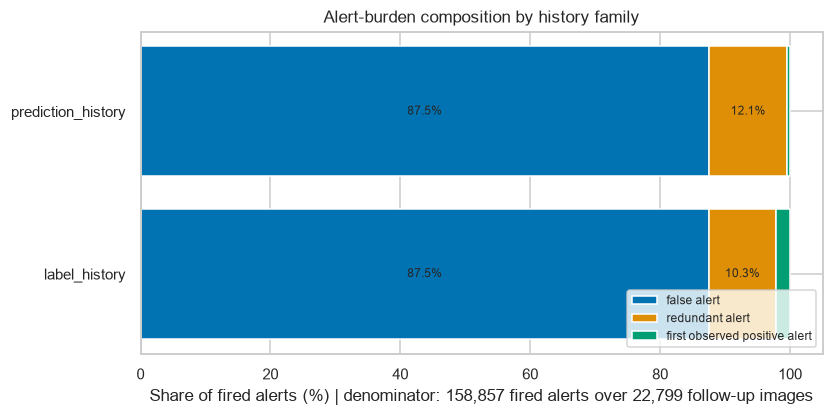

  figure -> fig06_burden_by_pathology.png


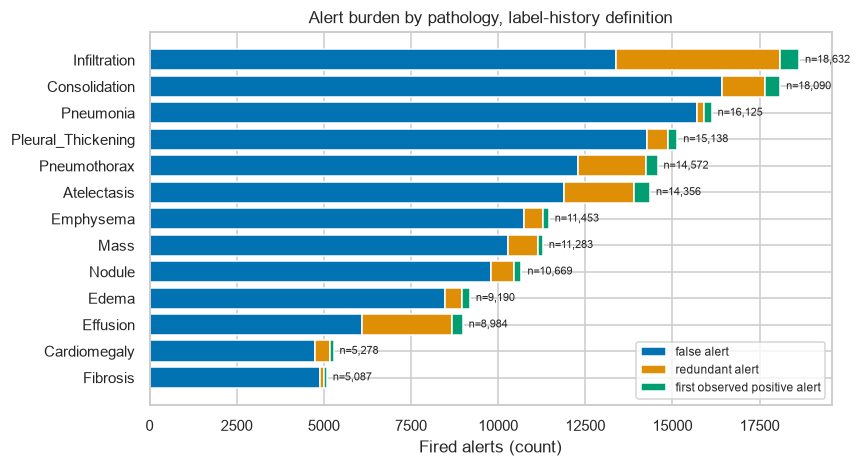

  figure -> fig07_alerts_per_patient.png


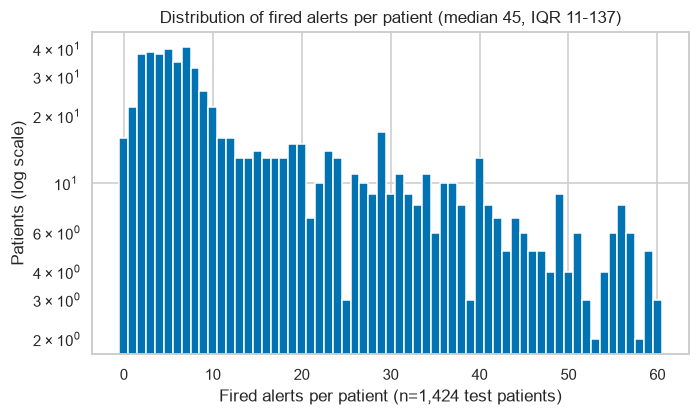

  figure -> fig08_burden_by_position.png


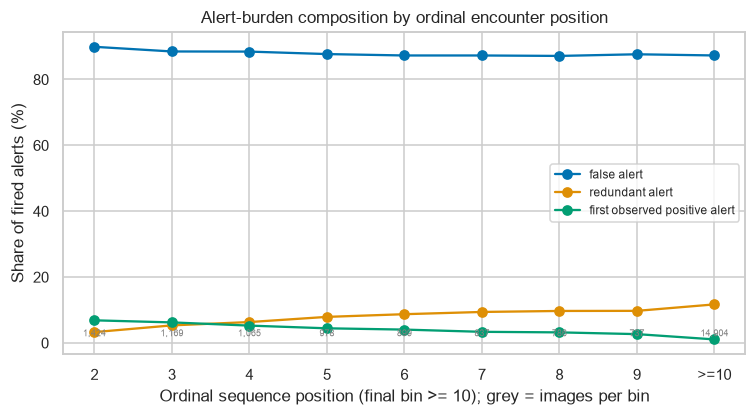

In [116]:
# ------------------------------- figures 5 to 8 -------------------------------
comp = (pd.concat([burden_label.assign(family="label_history"),
                   burden_pred.assign(family="prediction_history")])
        .query("alert_category in @FIRED_CATEGORIES"))
fig, ax = plt.subplots(figsize=(8, 3.8))
fams = ["label_history", "prediction_history"]
left = np.zeros(len(fams))
for i, cat in enumerate(FIRED_CATEGORIES):
    vals = [float(comp[(comp["family"] == f) & (comp["alert_category"] == cat)]
                  ["share_of_fired_alerts_pct"].iat[0]) for f in fams]
    ax.barh(fams, vals, left=left, color=CB[i], label=cat.replace("_", " "))
    for y, (v, l) in enumerate(zip(vals, left)):
        if v > 4:
            ax.text(l + v / 2, y, f"{v:.1f}%", ha="center", va="center", fontsize=8)
    left += np.asarray(vals)
n_fired = int(burden_label["total_fired_alerts"].iat[0])
ax.set_xlabel(f"Share of fired alerts (%) | denominator: {n_fired:,} fired alerts over "
              f"{int(burden_label['n_followup_images'].iat[0]):,} follow-up images")
ax.set_title("Alert-burden composition by history family")
ax.legend(loc="lower right", fontsize=8)
save_figure(fig, "fig05_burden_composition")
plt.show()

sub = by_path[by_path["redundancy_definition"] == PRIMARY_REDUNDANCY_DEFINITION].copy()
sub = sub.sort_values("total_fired", ascending=True)
fig, ax = plt.subplots(figsize=(8, 4.4))
left = np.zeros(len(sub))
for i, cat in enumerate(FIRED_CATEGORIES):
    ax.barh(sub["pathology"], sub[cat], left=left, color=CB[i],
            label=cat.replace("_", " "))
    left += sub[cat].to_numpy()
for y, (n, im) in enumerate(zip(sub["total_fired"], sub["n_images"])):
    ax.text(n, y, f"  n={n:,}", va="center", fontsize=7)
ax.set_xlabel("Fired alerts (count)")
ax.set_title("Alert burden by pathology, label-history definition")
ax.legend(loc="lower right", fontsize=8)
save_figure(fig, "fig06_burden_by_pathology")
plt.show()

per_pt = (CLS_LABEL[CLS_LABEL["alert_category"].isin(FIRED_CATEGORIES)]
          .groupby("Patient ID").size()
          .reindex(CLS_LABEL["Patient ID"].unique(), fill_value=0))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(per_pt.values, bins=np.arange(-0.5, min(per_pt.max(), 60) + 1.5, 1), color=CB[0])
ax.set_yscale("log")
ax.set_xlabel(f"Fired alerts per patient (n={len(per_pt):,} test patients)")
ax.set_ylabel("Patients (log scale)")
ax.set_title(f"Distribution of fired alerts per patient (median "
             f"{per_pt.median():.0f}, IQR {per_pt.quantile(.25):.0f}"
             f"-{per_pt.quantile(.75):.0f})")
save_figure(fig, "fig07_alerts_per_patient")
plt.show()

pos_lab = by_pos[by_pos["redundancy_definition"] == PRIMARY_REDUNDANCY_DEFINITION].copy()
order = [str(i) for i in range(2, POS_CAP)] + [f">={POS_CAP}"]
pos_lab["position_bin"] = pd.Categorical(pos_lab["position_bin"], order, ordered=True)
pos_lab = pos_lab.sort_values("position_bin").dropna(subset=["position_bin"])
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, cat in enumerate(FIRED_CATEGORIES):
    ax.plot(pos_lab["position_bin"].astype(str), pos_lab[f"share_{cat}_pct"],
            marker="o", color=CB[i], label=cat.replace("_", " "))
for x, n in zip(pos_lab["position_bin"].astype(str), pos_lab["n_images"]):
    ax.annotate(f"{n:,}", (x, 2), fontsize=6, ha="center", color="grey")
ax.set_xlabel(f"Ordinal sequence position (final bin >= {POS_CAP}); grey = images per bin")
ax.set_ylabel("Share of fired alerts (%)")
ax.set_title("Alert-burden composition by ordinal encounter position")
ax.legend(fontsize=8)
save_figure(fig, "fig08_burden_by_position")
plt.show()

## 12. Simulate alert-suppression policies

All five policies operate on exactly the same frozen held-out prediction stream at the
same locked thresholds. Only the firing rule differs.

| Policy | Rule | Status |
|---|---|---|
| `baseline` | fire whenever probability >= threshold | reference |
| `prediction_one_alert_ever` | fire only the first model-positive alert per patient-pathology within the test sequence | deployable-style |
| `prediction_immediate_repeat_suppression` | suppress when the model fired at the immediately preceding test encounter | deployable-style |
| `prediction_threshold_crossing` | fire only when probability crosses from below to at/above threshold versus the prior test encounter | deployable-style |
| `label_historical_oracle` | fire only when the label was never positive earlier in the test sequence | retrospective oracle benchmark, not deployable |

The oracle policy shows a theoretical upper bound on suppression under complete and
correct positive-label history. It is not implementable and is labelled as such
everywhere it appears.

Wording is deliberate throughout: alerts are *suppressed under a simulated policy* and
first-observed positive alerts are *retained*. Nothing here is safe, unnecessary, or
shown to reduce alert fatigue or improve outcomes.

  table  -> suppression_policy_comparison.csv  (5 x 17)
  table  -> suppression_policy_by_pathology.csv  (65 x 5)
                                           policy  total_fired_alerts  alerts_per_100_followup_images  pct_reduction_vs_baseline  first_observed_positive_alert_retention_pct  patients_losing_all_baseline_first_observed_positive_alerts
                                         baseline              158857                         696.772                      0.000                                      100.000                                                            0
                        prediction_one_alert_ever                8017                          35.164                     94.953                                       14.012                                                          631
prediction_immediate_repeat_or_threshold_crossing               40330                         176.894                     74.612                                       30.233        

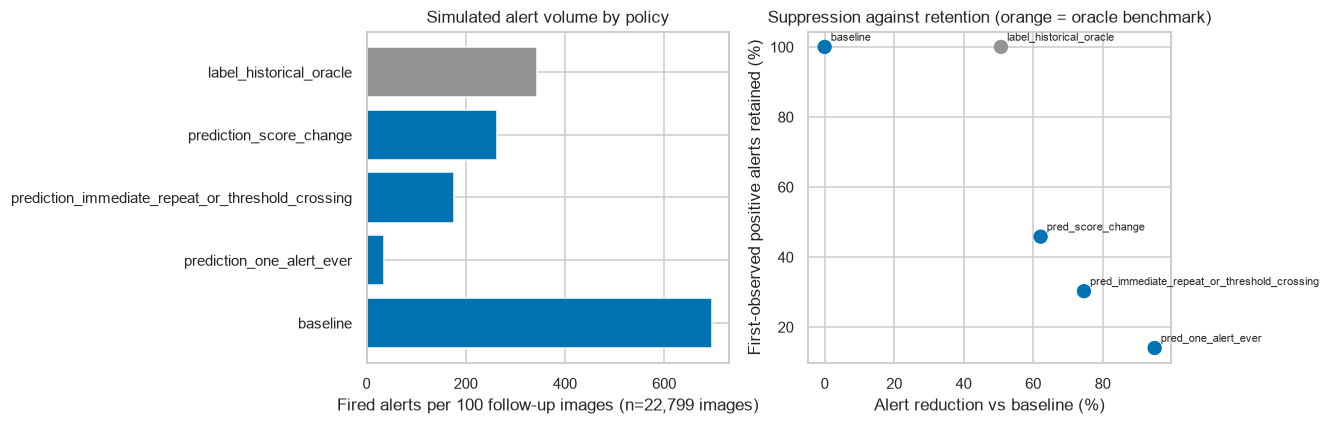

In [118]:
def apply_policy(stream: pd.DataFrame, policy: str) -> pd.Series:
    """Return the boolean firing decision for one simulated policy."""
    fires = stream["model_fires"] == 1
    if policy == "baseline":
        return fires
    if policy == "prediction_one_alert_ever":
        return fires & ~stream["fired_ever_prior"].fillna(False).astype(bool)
    if policy == "prediction_immediate_repeat_or_threshold_crossing":
        # At a fixed threshold these are algebraically the same condition:
        # the prior encounter not firing IS the prior probability being below threshold.
        # Carried as one policy rather than two apparently independent ones.
        return fires & ~stream["fired_prior_encounter"].eq(1)
    if policy == "prediction_score_change":
        prior_p = stream["prior_probability"]
        return fires & prior_p.notna() & (
            (stream["probability"] - prior_p) >= SCORE_CHANGE_DELTA)
    if policy == "label_historical_oracle":
        return fires & ~stream["label_ever_prior"].fillna(False).astype(bool)
    raise ValueError(f"Unknown policy {policy!r}")


POLICIES = ["baseline", "prediction_one_alert_ever",
            "prediction_immediate_repeat_or_threshold_crossing",
            "prediction_score_change", "label_historical_oracle"]
POLICY_STATUS = {
    "baseline": "reference",
    "prediction_one_alert_ever": "deployable_style",
    "prediction_immediate_repeat_or_threshold_crossing": "deployable_style",
    "prediction_score_change": f"deployable_style_score_change_delta_{SCORE_CHANGE_DELTA}",
    "label_historical_oracle": "retrospective_oracle_benchmark_not_deployable"}

base = _cohort(STREAM, SPEC_PRIMARY)
n_img = base["Image Index"].nunique()
n_pt = base["Patient ID"].nunique()
lab_prior = base["label_ever_prior"].fillna(False).astype(bool)
pred_prior = base["fired_ever_prior"].fillna(False).astype(bool)
pos = base["label_current"] == 1

baseline_fire = apply_policy(base, "baseline")
baseline_first_obs = baseline_fire & pos & ~lab_prior
baseline_first_by_pt = base.loc[baseline_first_obs].groupby("Patient ID").size()
baseline_n = int(baseline_fire.sum())

rows, by_path_rows = [], []
for pol in POLICIES:
    f = apply_policy(base, pol)
    n = int(f.sum())
    first_obs = f & pos & ~lab_prior
    fo_by_pt = base.loc[first_obs].groupby("Patient ID").size()
    lost = int(((baseline_first_by_pt > 0)
                & (fo_by_pt.reindex(baseline_first_by_pt.index, fill_value=0) == 0)).sum())
    per_pt = base.loc[f].groupby("Patient ID").size().reindex(
        base["Patient ID"].unique(), fill_value=0)
    rows.append({
        "policy": pol, "status": POLICY_STATUS[pol],
        "total_fired_alerts": n,
        "alerts_per_100_followup_images": round(100 * n / n_img, 3) if n_img else np.nan,
        "alerts_per_patient": round(n / n_pt, 4) if n_pt else np.nan,
        "false_alerts": int((f & ~pos).sum()),
        "label_history_redundant_alerts": int((f & pos & lab_prior).sum()),
        "prediction_history_redundant_alerts": int((f & pos & pred_prior).sum()),
        "first_observed_positive_alerts": int(first_obs.sum()),
        "alert_reduction_vs_baseline": baseline_n - n,
        "pct_reduction_vs_baseline": round(100 * (baseline_n - n) / baseline_n, 3)
        if baseline_n else np.nan,
        "first_observed_positive_alert_retention_pct": round(
            100 * int(first_obs.sum()) / max(int(baseline_first_obs.sum()), 1), 3),
        "false_alert_reduction_vs_baseline":
            int((baseline_fire & ~pos).sum()) - int((f & ~pos).sum()),
        "patients_with_at_least_one_alert": int((per_pt > 0).sum()),
        "patients_losing_all_baseline_first_observed_positive_alerts": lost,
        "median_alerts_per_patient": float(per_pt.median()),
        "iqr_alerts_per_patient": f"{per_pt.quantile(.25):.1f}-{per_pt.quantile(.75):.1f}",
    })
    g = base.assign(_f=f).groupby("pathology", observed=True).agg(
        fired=("_f", "sum"), opportunities=("_f", "size"))
    g["policy"], g["status"] = pol, POLICY_STATUS[pol]
    by_path_rows.append(g.reset_index())

policy_cmp = pd.DataFrame(rows)
save_table(policy_cmp, "suppression_policy_comparison")
save_table(pd.concat(by_path_rows, ignore_index=True),
           "suppression_policy_by_pathology")

print(policy_cmp[["policy", "total_fired_alerts", "alerts_per_100_followup_images",
                  "pct_reduction_vs_baseline",
                  "first_observed_positive_alert_retention_pct",
                  "patients_losing_all_baseline_first_observed_positive_alerts"]]
      .to_string(index=False))

print(f"\nprediction_score_change fires only when the probability rises by at least "
      f"{SCORE_CHANGE_DELTA} versus the immediately prior held-out encounter. This is a "
      "score-change heuristic on model output. It is not evidence of radiographic change, "
      "clinical worsening, or safe suppression.")
print("\nThe oracle row is a retrospective benchmark under complete and correct "
      "positive-label history. It is not deployable and bounds what any prediction-history "
      "policy could achieve.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
c = [CB[7] if POLICY_STATUS[p].startswith("retro") else CB[0] for p in policy_cmp["policy"]]
axes[0].barh(policy_cmp["policy"], policy_cmp["alerts_per_100_followup_images"], color=c)
axes[0].set_xlabel(f"Fired alerts per 100 follow-up images (n={n_img:,} images)")
axes[0].set_title("Simulated alert volume by policy")
_RET = "first_observed_positive_alert_retention_pct"
axes[1].scatter(policy_cmp["pct_reduction_vs_baseline"],
                policy_cmp[_RET], c=c, s=70)
for _, r in policy_cmp.iterrows():
    axes[1].annotate(r["policy"].replace("prediction_", "pred_"),
                     (r["pct_reduction_vs_baseline"], r[_RET]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("Alert reduction vs baseline (%)")
axes[1].set_ylabel("First-observed positive alerts retained (%)")
axes[1].set_title("Suppression against retention (orange = oracle benchmark)")
fig.tight_layout()
save_figure(fig, "fig09_policy_comparison")
plt.show()

## 13. Descriptive subgroup and sequence-position analyses

Descriptive only. These are unadjusted counts and rates across groups that differ in
prevalence, acquisition context and imaging frequency. Differences here are not evidence
of bias, and no causal or fairness conclusion is drawn from them.

Cells below the configured minima retain their counts but are flagged unstable, and
their rates are not interpreted.

  table  -> subgroup_descriptive_burden.csv  (17 x 21)
        subgroup           level  n_images  n_patients  total_fired  fired_per_100_images  share_false_alert_pct  share_redundant_alert_pct  share_first_observed_positive_alert_pct  pct_reduction_one_alert_ever  unstable_cell
       sex_group               F      9474         599        66271               699.504                 87.621                     10.182                                    2.197                        94.747          False
       sex_group               M     13325         825        92586               694.829                 87.448                     10.409                                    2.143                        95.101          False
        age_band           40-60     10552         702        74811               708.975                 87.359                     10.434                                    2.207                        94.880          False
        age_band             <40      727

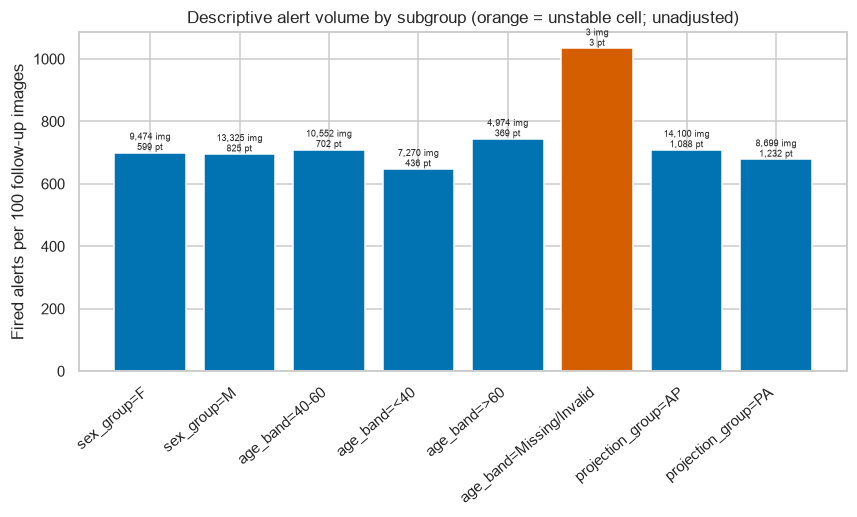

  figure -> fig11_position_descriptive.png


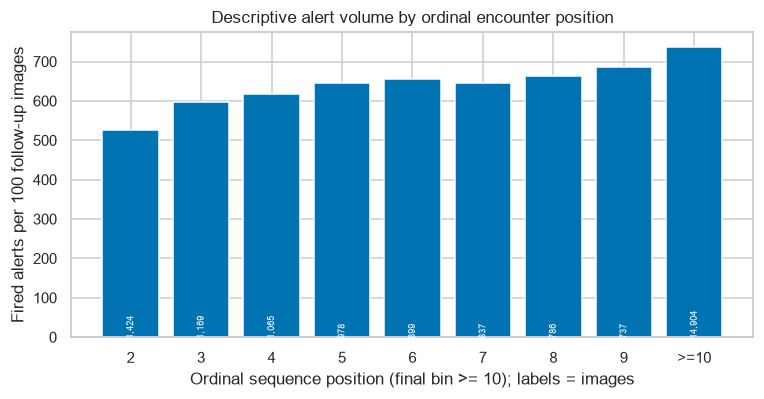

In [119]:
def subgroup_burden(classified: pd.DataFrame, col: str,
                    spec: BurdenSpec) -> pd.DataFrame:
    """Descriptive burden within levels of one covariate, with sparse-cell flags."""
    out = burden_by(classified, col, spec).rename(columns={col: "level"})
    out.insert(0, "subgroup", col)
    out["n_positive_opportunities"] = (
        classified.groupby(col, observed=True)["label_current"].sum().reindex(
            out["level"]).to_numpy())
    out["unstable_cell"] = (
        (out["n_images"] < MIN_SUBGROUP_IMAGES)
        | (out["n_patients"] < MIN_SUBGROUP_PATIENTS)
        | (out["n_positive_opportunities"] < MIN_SUBGROUP_POSITIVES))
    out["instability_reason"] = np.select(
        [out["n_images"] < MIN_SUBGROUP_IMAGES,
         out["n_patients"] < MIN_SUBGROUP_PATIENTS,
         out["n_positive_opportunities"] < MIN_SUBGROUP_POSITIVES],
        [f"<{MIN_SUBGROUP_IMAGES} images", f"<{MIN_SUBGROUP_PATIENTS} patients",
         f"<{MIN_SUBGROUP_POSITIVES} positives"], default="")
    return out


sub_rows = []
for col in ("sex_group", "age_band", "projection_group", "position_bin"):
    if col not in CLS_LABEL.columns:
        continue
    sub_rows.append(subgroup_burden(CLS_LABEL, col, SPEC_PRIMARY))
subgroups = pd.concat(sub_rows, ignore_index=True)

pol_red = []
for _, r in subgroups.iterrows():
    m = base[base[r["subgroup"]].astype(str) == str(r["level"])]
    if not len(m):
        pol_red.append(np.nan); continue
    b = int(apply_policy(m, "baseline").sum())
    o = int(apply_policy(m, "prediction_one_alert_ever").sum())
    pol_red.append(round(100 * (b - o) / b, 3) if b else np.nan)
subgroups["pct_reduction_one_alert_ever"] = pol_red
subgroups["pct_missing_level"] = 0.0
save_table(subgroups, "subgroup_descriptive_burden")

cols = ["subgroup", "level", "n_images", "n_patients", "total_fired",
        "fired_per_100_images", "share_false_alert_pct", "share_redundant_alert_pct",
        "share_first_observed_positive_alert_pct", "pct_reduction_one_alert_ever",
        "unstable_cell"]
print(subgroups[subgroups["subgroup"] != "position_bin"][cols].to_string(index=False))
_uns = int(subgroups["unstable_cell"].sum())
print(f"\n{_uns} cell(s) fall below the stability minima "
      f"(images<{MIN_SUBGROUP_IMAGES}, patients<{MIN_SUBGROUP_PATIENTS}, "
      f"positives<{MIN_SUBGROUP_POSITIVES}). Counts retained; rates not interpreted.")

plot_df = subgroups[(subgroups["subgroup"] != "position_bin")].copy()
fig, ax = plt.subplots(figsize=(9, 4))
xl = plot_df["subgroup"] + "=" + plot_df["level"].astype(str)
bars = ax.bar(xl, plot_df["fired_per_100_images"],
              color=[CB[3] if u else CB[0] for u in plot_df["unstable_cell"]])
for b, n_i, n_p in zip(bars, plot_df["n_images"], plot_df["n_patients"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{n_i:,} img\n{n_p:,} pt", ha="center", va="bottom", fontsize=6)
ax.set_ylabel("Fired alerts per 100 follow-up images")
ax.set_title("Descriptive alert volume by subgroup (orange = unstable cell; unadjusted)")
plt.xticks(rotation=40, ha="right")
save_figure(fig, "fig10_subgroup_descriptive")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.6))
pp = subgroups[subgroups["subgroup"] == "position_bin"].copy()
pp["level"] = pd.Categorical(pp["level"], order, ordered=True)
pp = pp.sort_values("level").dropna(subset=["level"])
ax.bar(pp["level"].astype(str), pp["fired_per_100_images"], color=CB[0])
for x, n in zip(pp["level"].astype(str), pp["n_images"]):
    ax.text(x, 0.5, f"{n:,}", ha="center", fontsize=6, rotation=90, color="white")
ax.set_xlabel(f"Ordinal sequence position (final bin >= {POS_CAP}); labels = images")
ax.set_ylabel("Fired alerts per 100 follow-up images")
ax.set_title("Descriptive alert volume by ordinal encounter position")
save_figure(fig, "fig11_position_descriptive")
plt.show()

## 14. Save outputs and Part 2 audit checklist

In [120]:
REQUIRED_TABLES = [
    "part2_cohort_flow.csv", "patient_split_assignments.csv",
    "split_integrity_audit.csv", "split_balance_audit.csv",
    "pathology_selection_report.csv", "embedding_cache_audit.csv",
    "training_history.csv", "validation_metrics.csv",
    "validation_threshold_grid.csv", "selected_thresholds.csv",
    "test_image_level_metrics.csv", "test_predictions_long.parquet",
    "test_alert_stream.parquet", "primary_alert_burden_label_history.csv",
    "primary_alert_burden_prediction_history.csv", "alert_burden_by_pathology.csv",
    "alert_burden_by_sequence_position.csv", "test_warmup_encounter_audit.csv",
    "suppression_policy_comparison.csv", "subgroup_descriptive_burden.csv",
    "age_consistency_audit.csv", "alert_burden_sensitivity_analyses.csv",
]
REQUIRED_FIGURES = [f"fig{i:02d}" for i in range(1, 12)]

missing_tables = [t for t in REQUIRED_TABLES if t not in _SAVED_TABLES]
missing_figs = [f for f in REQUIRED_FIGURES
                if not any(s.startswith(f) for s in _SAVED_FIGURES)]

checks = [
    ("Part 1 artifacts found", "PASS", f"{len(p1_wide):,} images"),
    ("Part 1 fingerprint matches",
     "PASS" if FP["fingerprint_match"] else "WARN", FP["fingerprint_recomputed"][:12]),
    ("image IDs unique", "PASS" if not p1_wide["Image Index"].duplicated().any() else "FAIL",
     "wide table"),
    ("long-table integrity",
     "PASS" if len(p1_long) == len(p1_wide) * len(PATHOLOGIES) else "FAIL",
     f"{len(p1_long):,} rows"),
    ("model cohort has linked images",
     "PASS" if bool(model_pool["image_exists"].all()) else "FAIL",
     f"{len(model_pool):,} images"),
    ("zero patient overlap across splits",
     "PASS" if int((wide.groupby('Patient ID')['split'].nunique() > 1).sum()) == 0 else "FAIL",
     SPLIT_INFO["split_source"]),
    ("thresholds selected on validation only",
     "PASS" if bool((THRESHOLDS["selected_on"] == "validation_split_only").all()) else "FAIL",
     f"{int(THRESHOLDS['fallback_used'].sum())} fallback(s)"),
    ("selected labels meet positive-count rules",
     "PASS" if bool(label_report.loc[label_report["status"] == "primary",
                                     "eligible"].all()) else "FAIL",
     f"{len(PRIMARY_LABELS)} labels"),
    ("pretrained embedding cache verified",
     "PASS" if emb_meta.get("pretrained_weights_used") else "FAIL",
     str(emb_meta.get("backbone_id"))),
    ("no random-weight cache used",
     "PASS" if emb_meta.get("pretrained_weights_used") else "FAIL", "enforced at load"),
    ("model checkpoint saved",
     "PASS" if (LOGS / "best_head.pt").exists() else "FAIL", "best_head.pt"),
    ("test predictions complete",
     "PASS" if not test_pred_long[["probability", "label_current"]].isna().any().any()
     else "FAIL", f"{len(test_pred_long):,} rows"),
    ("no duplicate test image-pathology rows",
     "PASS" if not test_pred_long.duplicated(["Image Index", "pathology"]).any() else "FAIL",
     "unique"),
    ("test history isolated from train/validation",
     "PASS" if not ISO["sequence_fragmented"] else "WARN",
     f"{ISO['test_patient_images_outside_test_split']:,} outside-split images"),
    ("index encounters excluded from primary cohort",
     "PASS" if not bool(CLS_LABEL["is_index_encounter"].any()) else "FAIL",
     f"{int(STREAM['is_index_encounter'].sum()):,} excluded"),
    ("warm-up encounters handled as pre-specified",
     "PASS" if not bool(CLS_LABEL["is_test_sequence_warmup_encounter"].any()) else "FAIL",
     "excluded from primary; sensitivity reported"),
    ("alert categories mutually exclusive",
     "PASS" if set(CLS_LABEL["alert_category"].unique()) <= set(ALERT_CATEGORIES) else "FAIL",
     f"{len(ALERT_CATEGORIES)} categories"),
    ("history families kept distinct",
     "PASS" if burden_label["history_family"].iat[0] != burden_pred["history_family"].iat[0]
     else "FAIL", "label vs prediction"),
    ("model saw embeddings only",
     "PASS" if Xtr.shape[1] == emb_meta["embedding_dim"] else "FAIL",
     "no history features"),
    ("all required tables saved",
     "PASS" if not missing_tables else "FAIL", f"missing: {missing_tables or 'none'}"),
    ("all required figures saved",
     "PASS" if not missing_figs else "FAIL", f"missing: {missing_figs or 'none'}"),
    ("run mode", "WARN" if FAST_MODE else "PASS",
     "SMOKE TEST - not the full analysis" if FAST_MODE else "full analysis"),
]
checklist = pd.DataFrame(checks, columns=["check", "status", "detail"])
print(checklist.to_string(index=False))
save_table(checklist, "part2_audit_checklist")

RUN_MANIFEST = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "run_tag": RUN_TAG, "fast_mode": FAST_MODE,
    "part1_fingerprint": FP, "split_info": SPLIT_INFO,
    "primary_labels": PRIMARY_LABELS,
    "selected_thresholds": THRESH_MAP,
    "embedding_meta": {k: v for k, v in emb_meta.items() if k != "status"},
    "n_test_images": int(dte["Image Index"].nunique()),
    "n_primary_cohort_rows": int(len(CLS_LABEL)),
    "tables_saved": sorted(_SAVED_TABLES), "figures_saved": sorted(_SAVED_FIGURES),
    "config": CONFIG,
}
(LOGS / "part2_run_manifest.json").write_text(json.dumps(RUN_MANIFEST, indent=2, default=str))

n_fail = int((checklist["status"] == "FAIL").sum())
n_warn = int((checklist["status"] == "WARN").sum())
print(f"\n{'=' * 74}")
print(f"PART 2 RESULT: {n_fail} FAIL, {n_warn} WARN, "
      f"{int((checklist['status'] == 'PASS').sum())} PASS   [{RUN_TAG.upper()} RUN]")
print("Resolve every FAIL before interpreting anything." if n_fail
      else ("Smoke test complete. Set FAST_MODE = False for the full analysis."
            if FAST_MODE else "Full analysis complete. Artifacts ready for Part 3."))
print("=" * 74)
gc.collect()

                                        check status                                      detail
                       Part 1 artifacts found   PASS                              112,120 images
                   Part 1 fingerprint matches   PASS                                ff1425a89979
                             image IDs unique   PASS                                  wide table
                         long-table integrity   PASS                              1,569,680 rows
               model cohort has linked images   PASS                              112,120 images
           zero patient overlap across splits   PASS                                official_nih
       thresholds selected on validation only   PASS                               0 fallback(s)
    selected labels meet positive-count rules   PASS                                   13 labels
          pretrained embedding cache verified   PASS                    densenet121_xrv_mimic_ch
                  no random-we

32426

In [122]:
d = CLS_LABEL[CLS_LABEL["label_current"] == 1].copy()
d["prior_positive"] = d["label_ever_prior"].fillna(False).astype(bool)
d["detected"] = d["alert_category"].isin(
    ["redundant_alert", "first_observed_positive_alert"])
o = d.groupby("prior_positive")["detected"].agg(n="size", detected="sum")
o["sensitivity"] = (o["detected"] / o["n"]).round(4)
print(o, "\n")
b = d.groupby(["pathology", "prior_positive"])["detected"].agg(n="size", detected="sum")
b["sens"] = (b["detected"] / b["n"]).round(3)
print(b["sens"].unstack("prior_positive").rename(
    columns={False: "first_observed", True: "repeat"}))

                    n  detected  sensitivity
prior_positive                              
False            5127      3440       0.6710
True            20729     16385       0.7904 

prior_positive      first_observed  repeat
pathology                                 
Atelectasis                  0.707   0.810
Cardiomegaly                 0.457   0.570
Consolidation                0.881   0.962
Edema                        0.689   0.813
Effusion                     0.474   0.664
Emphysema                    0.635   0.682
Fibrosis                     0.503   0.494
Infiltration                 0.768   0.908
Mass                         0.509   0.669
Nodule                       0.533   0.617
Pleural_Thickening           0.762   0.868
Pneumonia                    0.743   0.816
Pneumothorax                 0.848   0.872


## 15. Limitations, safeguards, and handoff to Part 3

### 15.1 What these results are conditional on

Every number above is conditional on the NIH weak labels, the frozen ImageNet-derived
representation, this particular patient-level split, the thresholds selected on this
validation set, and the history that happens to be observable in this corpus. Change any
one of those and the decomposition moves. Part 3 quantifies how much.

### 15.2 Limitations that constrain interpretation

1. **Repeated positive labels do not establish redundant clinical communication.** A
   finding present on a prior radiograph may still warrant re-alerting: it may have
   changed in extent, become newly relevant to management, or never have been
   communicated to the current clinician. The redundant category is a property of the
   label sequence, not of clinical value.
2. **First-observed positive labels do not establish incident disease or clinical
   actionability.** They mark the first positive weak label in the available sequence.
   Prior imaging outside this corpus is invisible, so this is an upper bound on first
   presentation.
3. **The split can fragment a patient's sequence.** When it does, the earliest test-split
   encounter has no test-side history. It is excluded from the primary decomposition and
   reported; the audit in section 10 states whether this occurred at all here.
4. **Label-history policies are retrospective oracle analyses.** They cannot be
   implemented, because a deployed system has no access to reference labels. They bound
   what prediction-history policies could achieve.
5. **Prediction-history policies are more operationally plausible but remain unvalidated
   workflows.** No clinician saw any of these alerts and no notification was delivered.
6. **No prospective clinical workflow, clinician, or patient-outcome data exist here.**
   Nothing in this notebook measures alert fatigue, trust, override behaviour, workload,
   cost, safety, or benefit, and no suppression policy may be described in those terms.
7. **Weak-label instability is not separable from clinical change.** A label flipping
   negative to positive between adjacent encounters is indistinguishable, in these data,
   from a finding genuinely appearing. This inflates the first-observed category by an
   unknown amount.
8. **Subgroup results are unadjusted descriptions.** Groups differ in prevalence,
   acquisition context and imaging frequency. No fairness or bias conclusion follows.
9. **Calibration has not been evaluated.** Thresholds were chosen on validation operating
   characteristics, not on calibrated risk.
10. **A single frozen representation was used.** The linear head cannot compensate for a
    representation trained on natural images rather than radiographs.

### 15.3 Safeguards implemented in code

- Splits are patient-disjoint and asserted, not assumed.
- Test-side history is recomputed within the test split, so no train or validation
  encounter can enter a history window even if a future split were not disjoint.
- The feature matrix is frozen embeddings only; no sequence, history, or identifier
  variable can reach the model.
- Thresholds are locked to disk before any test quantity is computed.
- Random-weight embedding caches are rejected at load time.
- Alert categories are asserted mutually exclusive and exhaustive on every cohort.
- Warm-up handling was pre-specified and its effect is audited rather than assumed.
- Smoke-test outputs are written to a separate directory and stamped `smoke_test=True`.

### 15.4 Handoff to Part 3

Part 3 will address uncertainty and robustness: interval estimation for the burden
fractions, sensitivity to threshold choice across the operating range, sensitivity to
the sequence and redundancy definitions, the strict-history cohort, alternative
backbones where locally available, and the NIH-Google adjudicated-label subset as an
restricted within-dataset label-reference sensitivity analysis. Those adjudicated labels
are a relabelling of ChestX-ray14 images, not an external dataset, and cannot support any
claim about external validation or transportability.

Artifacts carried forward: `test_predictions_long.parquet`, `test_alert_stream.parquet`,
`selected_thresholds.csv`, the model checkpoint, and `part2_run_manifest.json`.